In [80]:
import pandas as pd
import numpy as np
import tqdm

In [81]:
!pip install python-calamine


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [82]:
df_wide = pd.read_excel('pswci2_05_wide.xlsx', engine='calamine')
df_wide.head()

,pid,p05,nonresponse05,workperiod14,accident,injurytype,injurypart,con16,acc1,hire1,...,I01009001,I01009002,I01009003,I01010001,I01010002,I01010003,I01011001,I01011001t,I01012001,I01012001t
0,1,2,2.0,7,1,1,9,6,2014,2013,...,2,NaN,NaN,1,NaN,2.0,1,NaN,3,NaN
1,2,1,NaN,10,2,13,1,6,2012,2008,...,2,NaN,NaN,2,NaN,NaN,5,NaN,6,NaN
2,3,1,NaN,7,1,1,9,6,2014,2013,...,2,NaN,NaN,2,NaN,NaN,3,NaN,2,NaN
3,4,1,NaN,12,2,13,1,6,2015,2009,...,2,NaN,NaN,1,3000.0,NaN,7,NaN,1,NaN
4,5,1,NaN,8,2,13,1,6,2012,2010,...,2,NaN,NaN,2,NaN,NaN,1,NaN,1,NaN


In [83]:
df_main = pd.read_excel('pswci2_05_main.xlsx', engine='calamine')
df_main.head()

,pid,p05,nonresponse03,workperiod14,accident,injurytype,injurypart,con16,acc1,hire1,...,I05009002,I05009003,I05010001,I05010002,I05010003,I05011001,I05011001t,I05012001,I05012001t,filter_$
0,1,2,2.0,7,1,1,9,6,2014,2013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,NaN,10,2,13,1,6,2012,2008,...,NaN,NaN,2.0,NaN,NaN,5.0,NaN,6.0,NaN,0.0
2,3,1,NaN,7,1,1,9,6,2014,2013,...,9000.0,NaN,2.0,NaN,NaN,4.0,NaN,1.0,NaN,0.0
3,4,1,NaN,12,2,13,1,6,2015,2009,...,NaN,NaN,1.0,10000.0,NaN,7.0,NaN,1.0,NaN,0.0
4,5,1,NaN,8,2,13,1,6,2012,2010,...,NaN,NaN,2.0,NaN,NaN,1.0,NaN,1.0,NaN,0.0


소비자물가지수, 서울시 생활임금

In [84]:
# 통계청 소비자물가지수 (2020=100 기준)
CPI = {3: 97.4, 4: 102.5, 5: 107.7}

# 서울시 생활임금 (월, 만원)
LIVING_WAGE = {3: 197.8, 4: 208.5, 5: 219.8}

ALPHA    = 0.4
NAN_VALS = [9999998, 9999999]

In [85]:
# 5차 실제 응답자 필터링(p05==1)
df = df_wide[df_wide['p05'] == 1].copy()
print(f"5차 응답자: {len(df)}명")

5차 응답자: 2728명


In [86]:
# ============================================================
# 소득 변수 정제
#    대상: 개인소득총계(H0x003036), 근로소득(H0x002005), 휴업급여(H0x003001)
#    처리: 결측코드 → NaN, 단위 만원/연 → 만원/월(÷12)
# ============================================================

income_raw_cols = (
    [f'H0{w}003036' for w in range(1, 6)] +   # 개인소득총계
    [f'H0{w}002005' for w in range(1, 6)] +   # 근로소득
    [f'H0{w}003001' for w in range(1, 6)]     # 휴업급여
)

for col in income_raw_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').replace(NAN_VALS, np.nan)

# 월 단위 파생 변수 생성
for w in range(1, 6):
    for suffix in ['003036', '002005', '003001']:
        col_ann = f'H0{w}{suffix}'
        col_mon = f'H0{w}{suffix}_m'          # _m = monthly
        if col_ann in df.columns:
            df[col_mon] = df[col_ann] / 12

print("\n[차수별 개인소득총계 (월, 만원)]")
for w in range(1, 6):
    col = f'H0{w}003036_m'
    s = df[col].dropna()
    print(f"  {w}차: n={len(s)}, 평균={s.mean():.1f}, 중앙={s.median():.1f}")


[차수별 개인소득총계 (월, 만원)]
  1차: n=2728, 평균=336.5, 중앙=281.2
  2차: n=2654, 평균=204.9, 중앙=185.0
  3차: n=2650, 평균=202.6, 중앙=195.0
  4차: n=2693, 평균=211.5, 중앙=200.0
  5차: n=2728, 평균=207.0, 중앙=200.0


In [87]:
# ============================================================
# RIRI 계산 - 소득회복율
#    RIRI_w = (Q_irr_w × W_pre / LW_w) × (CPI_pre / CPI_w) × 100
#
#    Q_irr  = H0x002005_m / H0x003036_m   (근로소득 비중, 0~1 클리핑)
#    W_pre  = H03003036_m                 (3차 기준 월 소득)
#    LW_w   = 해당 차수 생활임금 (월, 만원)
#    post 차수: 3차(자기기준), 4차, 5차
# ============================================================

W_pre = df['H03003036_m']  # 3차 기준 월 소득

for w in [3, 4, 5]:
    total_m = df[f'H0{w}003036_m']
    earn_m  = df[f'H0{w}002005_m'].fillna(0)

    # Q_irr: 총소득 > 0인 경우만 계산
    q_irr = np.where(
        total_m.notna() & (total_m > 0),
        (earn_m / total_m).clip(0, 1),
        np.nan
    )

    riri = (q_irr * (W_pre / LIVING_WAGE[w])) * (CPI[3] / CPI[w]) * 100

    # 상위 1% 윈저라이징
    upper = np.nanpercentile(riri, 99)
    riri  = np.where(riri > upper, upper, riri)

    df[f'RIRI_w{w}'] = riri

    n_valid = (~np.isnan(riri)).sum()
    print(f"\nRIRI_w{w}: 유효={n_valid} | "
          f"평균={np.nanmean(riri):.1f} | 중앙={np.nanmedian(riri):.1f} | "
          f"≥100: {(riri>=100).sum()}명({np.nanmean(riri>=100)*100:.1f}%) | "
          f"<50: {(riri<50).sum()}명({np.nanmean(riri<50)*100:.1f}%)")



RIRI_w3: 유효=2464 | 평균=86.4 | 중앙=84.3 | ≥100: 1094명(40.1%) | <50: 859명(31.5%)

RIRI_w4: 유효=2490 | 평균=72.5 | 중앙=69.1 | ≥100: 825명(30.2%) | <50: 1049명(38.5%)

RIRI_w5: 유효=2501 | 평균=67.5 | 중앙=65.2 | ≥100: 764명(28.0%) | <50: 1067명(39.1%)


In [88]:
# ============================================================
# RIRI 3분류 레이블
#    2 = 완전회복 (RIRI ≥ 100)
#    1 = 부분회복 (50 ≤ RIRI < 100)
#    0 = 미회복   (RIRI < 50)
# ============================================================

def classify_riri(x):
    if pd.isna(x):   return np.nan
    elif x >= 100:   return 2
    elif x >= 50:    return 1
    else:            return 0

for w in [3, 4, 5]:
    df[f'RIRI_class_w{w}'] = df[f'RIRI_w{w}'].apply(classify_riri)
    dist  = df[f'RIRI_class_w{w}'].value_counts().sort_index()
    total = dist.sum()
    label = {0: '미회복', 1: '부분회복', 2: '완전회복'}
    print(f"{w}차: " + " | ".join(
        [f"{label[k]}={v}({v/total*100:.1f}%)" for k, v in dist.items()]))


3차: 미회복=859(34.9%) | 부분회복=511(20.7%) | 완전회복=1094(44.4%)
4차: 미회복=1049(42.1%) | 부분회복=616(24.7%) | 완전회복=825(33.1%)
5차: 미회복=1067(42.7%) | 부분회복=670(26.8%) | 완전회복=764(30.5%)


In [89]:
# ============================================================
# 장해등급 변수 처리
#    disa052  : 장해 유무 (1=있음, 2=없음)
#    disa0515 : 실제 등급 (1~14=유장해, 15=무장해)
#    → disa_class: 0=무장해, 1=중증(1~7급), 2=경증(8~14급)
# ============================================================

df['disa0515_num'] = pd.to_numeric(df['disa0515'], errors='coerce')

def classify_disability(g):
    if pd.isna(g) or g == 15:  return 0   # 무장해
    elif g <= 7:               return 1   # 중증
    else:                      return 2   # 경증

df['disa_class'] = df['disa0515_num'].apply(classify_disability)

dist_d = df['disa_class'].value_counts().sort_index()
print(f"\n장해등급: 무장해={dist_d.get(0,0)}, 중증(1~7급)={dist_d.get(1,0)}, "
      f"경증(8~14급)={dist_d.get(2,0)}")


장해등급: 무장해=521, 중증(1~7급)=290, 경증(8~14급)=1917


In [90]:
# ============================================================
# 경제활동상태 재코딩 (차수별)
#    emp0x2: 1=취업, 2=실업, 3=비경활
# ============================================================

for w in range(1, 6):
    col = f'emp0{w}2'
    if col in df.columns:
        df[f'empstat_w{w}'] = pd.to_numeric(df[col], errors='coerce')
        df.loc[~df[f'empstat_w{w}'].isin([1, 2, 3]), f'empstat_w{w}'] = np.nan

print("\n[차수별 경제활동상태]")
emp_label = {1: '취업', 2: '실업', 3: '비경활'}
for w in range(1, 6):
    col = f'empstat_w{w}'
    if col in df.columns:
        dist = df[col].value_counts().sort_index()
        print(f"  {w}차: " + ", ".join(
            [f"{emp_label.get(k,'?')}={v}" for k, v in dist.items()]))


[차수별 경제활동상태]
  1차: 취업=1698, 실업=1030
  2차: 취업=1833, 실업=821
  3차: 취업=1846, 실업=804
  4차: 취업=1910, 실업=783
  5차: 취업=1910, 실업=818


In [91]:
# ============================================================
# 심리·건강 변수 처리
#    자아존중감  G0x021001: 원척도 1(매우그렇다)~4(전혀그렇지않다) → 역코딩
#    생활만족도  G0x022007: 전반적 생활만족도
#    주관적건강  G0x005001: 1=매우나쁨 ~ 4=매우좋음
# ============================================================

for w in range(1, 6):
    ww = f'0{w}'
    # 자아존중감 역코딩 (높을수록 긍정)
    ec = f'G{ww}021001'
    if ec in df.columns:
        df[f'esteem_w{w}'] = 5 - pd.to_numeric(df[ec], errors='coerce')

    # 전반적 생활만족도
    sc = f'G{ww}022007'
    if sc in df.columns:
        df[f'lifesatis_w{w}'] = pd.to_numeric(df[sc], errors='coerce')

    # 주관적 건강상태
    hc = f'G{ww}005001'
    if hc in df.columns:
        df[f'health_w{w}'] = pd.to_numeric(df[hc], errors='coerce')

print("\n[5차 심리·건강 기초통계]")
for col, label in [('esteem_w5','자아존중감'), ('lifesatis_w5','생활만족도'), ('health_w5','주관적건강')]:
    if col in df.columns:
        s = df[col].dropna()
        print(f"  {label}: M={s.mean():.2f}, SD={s.std():.2f}, n={len(s)}")



[5차 심리·건강 기초통계]
  자아존중감: M=2.11, SD=0.70, n=2728
  생활만족도: M=2.62, SD=0.66, n=2728
  주관적건강: M=2.58, SD=0.67, n=2728


In [92]:
# ============================================================
# 재활서비스 이진화
#    jobservice05: 직업재활 (훈련/취업지원)
#    socservice05: 사회재활 (심리상담/취미)
# ============================================================

for col, new_col in [('jobservice05', 'job_rehab'), ('socservice05', 'soc_rehab')]:
    if col in df.columns:
        s = pd.to_numeric(df[col], errors='coerce')
        df[new_col] = np.where(s.isna(), np.nan, (s >= 1).astype(float))

print(f"\n직업재활 이용: {df['job_rehab'].sum():.0f}명 | "
      f"사회재활 이용: {df['soc_rehab'].sum():.0f}명")



직업재활 이용: 435명 | 사회재활 이용: 489명


In [93]:
# ============================================================
# 최종 분석 데이터셋 구성 (LCGA 입력용)
# ============================================================

final_cols = [
    'pid',
    # Y 변수: RIRI (3~5차)
    'RIRI_w3', 'RIRI_w4', 'RIRI_w5',
    'RIRI_class_w3', 'RIRI_class_w4', 'RIRI_class_w5',
    # 원천 소득 (참고용)
    'H03003036', 'H04003036', 'H05003036',
    'H03002005', 'H04002005', 'H05002005',
    'H03003001', 'H04003001', 'H05003001',
    # 인구사회학적
    'gender', 'age054', 'edu05', 'area056',
    # 장해
    'disa052', 'disa0515_num', 'disa_class',
    # 재활서비스
    'service05', 'job_rehab', 'soc_rehab',
    # 경제활동상태 시계열
    'empstat_w1', 'empstat_w2', 'empstat_w3', 'empstat_w4', 'empstat_w5',
    # 자아존중감 시계열
    'esteem_w1', 'esteem_w2', 'esteem_w3', 'esteem_w4', 'esteem_w5',
    # 생활만족도 시계열
    'lifesatis_w1', 'lifesatis_w2', 'lifesatis_w3', 'lifesatis_w4', 'lifesatis_w5',
    # 주관적 건강상태 시계열
    'health_w1', 'health_w2', 'health_w3', 'health_w4', 'health_w5',
]

exist_cols = [c for c in final_cols if c in df.columns]
df_final   = df[exist_cols].copy()

# LCGA 대상: RIRI 3~5차 중 2개 시점 이상 유효
riri_obs = df_final[['RIRI_w3', 'RIRI_w4', 'RIRI_w5']].notna().sum(axis=1)
df_lcga  = df_final[riri_obs >= 2].copy()

print(f"\n최종 데이터: {df_final.shape}")
print(f"LCGA 분석 대상 (RIRI 2시점 이상): {len(df_lcga)}명")

# 결측 요약
print("\n[주요 변수 결측 요약]")
for col in ['RIRI_w3','RIRI_w4','RIRI_w5','disa_class','esteem_w1','lifesatis_w1']:
    if col in df_lcga.columns:
        miss = df_lcga[col].isna().sum()
        print(f"  {col}: 유효={df_lcga[col].notna().sum()}, 결측={miss}({miss/len(df_lcga)*100:.1f}%)")



최종 데이터: (2728, 46)
LCGA 분석 대상 (RIRI 2시점 이상): 2542명

[주요 변수 결측 요약]
  RIRI_w3: 유효=2436, 결측=106(4.2%)
  RIRI_w4: 유효=2482, 결측=60(2.4%)
  RIRI_w5: 유효=2472, 결측=70(2.8%)
  disa_class: 유효=2542, 결측=0(0.0%)
  esteem_w1: 유효=2542, 결측=0(0.0%)
  lifesatis_w1: 유효=2542, 결측=0(0.0%)


전처리 단계별 요약
1. 표본 선정
- 전체 패널 3,294명 중 5차년도 실제 응답자(p05 == 1)만 필터링 → 2,728명
- 탈락자(사망, 거절, 주소불명 등) 제외

2. 소득 변수 정제

사용 변수 3종 × 5개 차수 = 15개 변수 처리

- H0x003036 개인소득 총계 (근로+비근로 모두 포함)
- H0x002005 근로소득 총계
- H0x003001 휴업급여 수령액
    - 응답거절(9999998), 모름(9999999) → NaN으로 치환
    - 단위 변환: 만원/연 → 만원/월 (÷12), _m 접미사로 저장

3. **RIRI** 계산

$RIRI_w = \frac{Q_{irr} * W_{pre}}{LW_w}*\frac{CPI_{pre}}{CPI_w}*100$

- Q_irr = H0x002005_m / H0x003036_m → 전체 소득 중 근로소득이 차지하는 비중 (0~1 클리핑)
- W_pre = H03003036_m → 3차년도 월 소득을 기준선(baseline)으로 고정
- LW_w = 해당 차수의 서울시 생활임금 (외부 상수)
- CPI 보정 = 물가 변동 반영 (3차 기준 → 4·5차 실질 비교)
- 상위 1% 윈저라이징 → 극단값 처리
- 3차·4차·5차 각각 계산 → RIRI_w3, RIRI_w4, RIRI_w5


4. RIRI 3분류 레이블 생성
- RIRI >= 100, 완전회복, 2
- 50 <= RIRI < 100, 부분회복, 1
- RIRI < 50, 미회복, 0

→ RIRI_class_w3/4/5 변수로 저장 (LCGA 보조 해석용)

5. 장해등급 3분류
- disa056, 6범주 (1~3급/4~7급/8~9급/10~12급/13~14급/무장해) -> disa_class_6
- disa0515, 15범주 (1~14급 + 15=무장해) -> disa_class (주 사용)

-> 0=무장해, 1=중증(1~7급), 2=경증(8~14급) 로 통일

6. 경제활동상태 재코딩
- emp0x31=취업자, 2=실업자, 3=비경활
    - 주 분석용 → empstat3_w1~5
- emp0x61=원직장복귀, 2=재취업, 3=자영업, 4=무급가족, 5=실업, 6=비경활
    - 복귀 유형 파악용 → empstat6_w1~5

7. 심리·건강 변수 처리
- G0x021001 자아존중감1=그렇지않다 ~ 4=항상그렇다
    - 그대로 (높을수록 긍정)
- G0x022007 생활만족도1=매우만족 ~ 5=매우불만족
    - 역코딩 (6-x) → 높을수록 만족
- G0x005001 주관적건강1=매우나쁨 ~ 4=매우좋음
    - 그대로 (높을수록 좋음)
- G0x023001~006 자기효능감1=전혀그렇지않다 ~ 5=매우그렇다
    - 6문항 평균 → efficacy_w1~5

8. 재활서비스 이진화
- 코드북: 1=이용, 2=미이용 (0이 미이용이 아님)
- 수정 후: 1→1, 2→0, 그 외→NaN 으로 변환
- any_rehab (전체), job_rehab (직업재활), soc_rehab (사회재활)

[CHECKPOINT]

기술 통계

In [94]:
# ============================================================
# 1. 인구사회학적 특성
# ============================================================

n = len(df_lcga)

print("\n" + "=" * 55)
print("1. 인구사회학적 특성")
print("=" * 55)

g = df_lcga['gender'].value_counts().sort_index()
print(f"\n성별: 남={g.get(1,0)}({g.get(1,0)/n*100:.1f}%), "
      f"여={g.get(2,0)}({g.get(2,0)/n*100:.1f}%)")

a_label = {1:'30대이하', 2:'40대', 3:'50대', 4:'60대이상'}
a = df_lcga['age054'].value_counts().sort_index()
print("연령대: " + " | ".join(
    [f"{a_label[k]}={v}({v/n*100:.1f}%)" for k,v in a.items()]))

e_label = {1:'무학', 2:'초졸', 3:'중졸', 4:'고졸', 5:'대졸이상'}
e = df_lcga['edu05'].value_counts().sort_index()
print("학력:   " + " | ".join(
    [f"{e_label[k]}={v}({v/n*100:.1f}%)" for k,v in e.items()]))

d_label = {0:'무장해', 1:'중증(1~7급)', 2:'경증(8~14급)'}
d = df_lcga['disa_class'].value_counts().sort_index()
print("장해:   " + " | ".join(
    [f"{d_label[k]}={v}({v/n*100:.1f}%)" for k,v in d.items()]))


1. 인구사회학적 특성

성별: 남=2105(82.8%), 여=437(17.2%)
연령대: 30대이하=238(9.4%) | 40대=370(14.6%) | 50대=688(27.1%) | 60대이상=1246(49.0%)
학력:   무학=74(2.9%) | 초졸=393(15.5%) | 중졸=470(18.5%) | 고졸=1139(44.8%) | 대졸이상=466(18.3%)
장해:   무장해=480(18.9%) | 중증(1~7급)=275(10.8%) | 경증(8~14급)=1787(70.3%)


In [95]:
# df_lcga에 원본 변수 전체 포함시키기
riri_obs = df[['RIRI_w3', 'RIRI_w4', 'RIRI_w5']].notna().sum(axis=1)
df_lcga  = df[riri_obs >= 2].copy()   # df 전체 컬럼 유지

In [96]:
# ============================================================
# 2. 재활서비스 이용 현황
# ============================================================

print("\n" + "=" * 55)
print("2. 재활서비스 이용 현황")
print("=" * 55)

# 코드북: 1=이용, 2=미이용
for col, label in [('jobservice05', '직업재활'), ('socservice05', '사회재활')]:
    # df_wide에서 pid 기준으로 가져오기
    if col in df.columns:
        merged = df_lcga[['pid']].merge(df[['pid', col]], on='pid', how='left')
        s   = pd.to_numeric(merged[col], errors='coerce')
        yes = (s == 1).sum()
        print(f"{label}: 이용={yes}({yes/n*100:.1f}%), "
              f"미이용={n-yes}({(n-yes)/n*100:.1f}%)")
    else:
        print(f"{col} 컬럼 없음")


2. 재활서비스 이용 현황
직업재활: 이용=397(15.6%), 미이용=2145(84.4%)
사회재활: 이용=444(17.5%), 미이용=2098(82.5%)


In [97]:
# ============================================================
# 3. RIRI 기술통계 (차수별)
# ============================================================

print("\n" + "=" * 55)
print("3. RIRI 기술통계 (차수별)")
print("=" * 55)

for w, year in [(3, 2020), (4, 2021), (5, 2022)]:
    s = df_lcga[f'RIRI_w{w}'].dropna()
    print(f"\n  {w}차({year}년): n={len(s)}")
    print(f"    평균={s.mean():.1f}, SD={s.std():.1f}, 중앙={s.median():.1f}")
    print(f"    Q1={s.quantile(.25):.1f}, Q3={s.quantile(.75):.1f}")
    print(f"    완전회복(≥100): {(s>=100).sum()}명({(s>=100).mean()*100:.1f}%)")
    print(f"    부분회복(50~99): {((s>=50)&(s<100)).sum()}명"
          f"({((s>=50)&(s<100)).mean()*100:.1f}%)")
    print(f"    미회복(<50):    {(s<50).sum()}명({(s<50).mean()*100:.1f}%)")




3. RIRI 기술통계 (차수별)

  3차(2020년): n=2436
    평균=86.6, SD=71.8, 중앙=84.3
    Q1=10.1, Q3=136.5
    완전회복(≥100): 1087명(44.6%)
    부분회복(50~99): 503명(20.6%)
    미회복(<50):    846명(34.7%)

  4차(2021년): n=2482
    평균=72.7, SD=65.9, 중앙=70.2
    Q1=0.1, Q3=115.8
    완전회복(≥100): 825명(33.2%)
    부분회복(50~99): 616명(24.8%)
    미회복(<50):    1041명(41.9%)

  5차(2022년): n=2472
    평균=68.2, SD=61.9, 중앙=65.8
    Q1=2.1, Q3=110.5
    완전회복(≥100): 764명(30.9%)
    부분회복(50~99): 670명(27.1%)
    미회복(<50):    1038명(42.0%)


In [98]:
# ============================================================
# 4. 경제활동상태 추이
# ============================================================

print("\n" + "=" * 55)
print("4. 경제활동상태 추이 (3범주, %)")
print("=" * 55)

for w in range(1, 6):
    col  = f'empstat_w{w}'
    dist = df_lcga[col].value_counts().sort_index()
    tot  = dist.sum()
    row  = " | ".join(
        [f"{emp_label.get(k,'?')}={v}({v/tot*100:.1f}%)" for k,v in dist.items()])
    print(f"  {w}차: {row}")


4. 경제활동상태 추이 (3범주, %)
  1차: 취업=1612(63.4%) | 실업=930(36.6%)
  2차: 취업=1770(71.1%) | 실업=721(28.9%)
  3차: 취업=1832(72.1%) | 실업=710(27.9%)
  4차: 취업=1852(73.4%) | 실업=670(26.6%)
  5차: 취업=1832(72.1%) | 실업=710(27.9%)


In [99]:
# ============================================================
# 5. 심리·건강 변수 기술통계
# ============================================================

print("\n" + "=" * 55)
print("5. 심리·건강 변수 기술통계")
print("=" * 55)

# 자아존중감 (G0x021001, 1~4, 높을수록 긍정)
# 생활만족도 (G0x022007, 역코딩 후 1~5, 높을수록 만족)
# 주관적건강 (G0x005001, 1~4, 높을수록 좋음)
for w in range(1, 6):
    ww = f'0{w}'
    ec = f'G{ww}021001'
    sc = f'G{ww}022007'
    hc = f'G{ww}005001'
    if ec in df_lcga.columns:
        df_lcga[f'esteem_w{w}']   = pd.to_numeric(df_lcga[ec], errors='coerce')
    if sc in df_lcga.columns:
        df_lcga[f'lifesatis_w{w}'] = 6 - pd.to_numeric(df_lcga[sc], errors='coerce')
    if hc in df_lcga.columns:
        df_lcga[f'health_w{w}']   = pd.to_numeric(df_lcga[hc], errors='coerce')

psych_vars = {
    'esteem_w1':   '자아존중감_1차(1~4)',
    'esteem_w3':   '자아존중감_3차',
    'esteem_w5':   '자아존중감_5차',
    'lifesatis_w1':'생활만족도_1차(역코딩1~5)',
    'lifesatis_w3':'생활만족도_3차',
    'lifesatis_w5':'생활만족도_5차',
    'health_w1':   '주관적건강_1차(1~4)',
    'health_w3':   '주관적건강_3차',
    'health_w5':   '주관적건강_5차',
}

for col, label in psych_vars.items():
    if col in df_lcga.columns:
        s = df_lcga[col].dropna()
        print(f"  {label}: M={s.mean():.2f}, SD={s.std():.2f}, n={len(s)}")


5. 심리·건강 변수 기술통계
  자아존중감_1차(1~4): M=2.70, SD=0.74, n=2542
  자아존중감_3차: M=2.86, SD=0.72, n=2542
  자아존중감_5차: M=2.90, SD=0.70, n=2542
  생활만족도_1차(역코딩1~5): M=3.21, SD=0.73, n=2542
  생활만족도_3차: M=3.31, SD=0.66, n=2542
  생활만족도_5차: M=3.39, SD=0.65, n=2542
  주관적건강_1차(1~4): M=2.50, SD=0.69, n=2542
  주관적건강_3차: M=2.58, SD=0.65, n=2542
  주관적건강_5차: M=2.59, SD=0.66, n=2542


### 기술통계량 해석
1. **인구사회학적 특성**
- **성별, 연령:**
    - 남성이 82.8%, 60대 이상이 49.0%
    - 산재 노동자 집단의 구조적 특성을 그대로 반영
    - 제조업, 건설업 중심의 육체노돌 종사자가 많고, 고령화가 진행된 국내 블루칼라 노동시장 특성과 일치.
- **학력:**
    - 고졸 이하가 81.7%
- **장해등급:**
    - 경증(8~14급) 70.3%, 가장 다수
    - 중증(1~7급) 10.8%
    - 장해가 경미한데도 소득이 회복 안 되는 집단이 존재한다면, **"정책 사각지대"**에 해당하는 집단.

2. **재활서비스 이용 현황**
- 직업재활 15.6%, 사회재활 17.5%로 둘 다 **이용률이 매우 낮음.**
    - 10명 중 8~9명은 아무 서비스도 이용하지 않은 것.

첫째, 서비스 접근성이나 인지도 자체에 문제가 있을 가능성이 있음.

둘째, 나중에 재활서비스 전환 효과 분석(3단계)을 할 때 이용 집단 표본이 작아서 통계적 검정력이 떨어질 수 있으니 미리 감안해야 함.

3. **RIRI 추이 ← 가장 중요**
- 평균:
    - 꾸준히 하락 (86.6 → 72.7 → 68.2). 
    - 시간이 지날수록 생활임금 대비 소득회복 수준이 낮아진다는 뜻. 
    - 물가 보정까지 했는데도 이렇게 나오는 거라서, 실질적인 경제적 악화가 진행되고 있는 것.
- 분산:
    - 극도로 큼 (SD 62~72, 평균과 거의 맞먹는 수준). 
    - LCGA 적용의 핵심 근거예요. 
    - 집단 평균만 보면 안 된다. 
    - 연구계획서에서 말한 "평균의 함정"이 여기서 실증.
- IQR:
    - 비대칭적으로 넓음. 
    - 3차의 Q1=10.1인데 Q3=136.5 
    - 하위 25%는 RIRI가 10 이하, 즉 생활임금의 10%도 안 되는 소득으로 살고 있는 반면, 상위 25%는 생활임금의 136% 이상을 벌고 있음. 
    - 이 극단적인 양극화 구조가 나중에 *LCGA에서 만성취약형과 안정회복형 두 집단으로 갈릴 가능성이 높*음.

완전회복 비율도 44.6% → 33.2% → 30.9%로 지속 감소하고, 미회복은 34.7% → 41.9% → 42.0%로 증가. 시간이 지나도 **회복이 안 되는 집단이 고착화되고 있다**는 신호.

4. **경제활동상태 추이**
- 취업률은 1차(63.4%)에서 2차(71.1%)로 급등한 뒤 이후 72~73%에서 고착.
- 이게 RIRI 하락과 같이 놓고 보면 흥미로운 지점. 
    - 취업은 하고 있는데 소득은 회복이 안 되는 것. 
    - 즉 재취업은 했지만 산재 이전보다 낮은 임금의 일자리에 머물러 있다는 뜻
    - 이게 연구에서 단순 취업 여부가 아니라 RIRI라는 소득회복 지표를 Y로 써야 하는 이유를 직접적으로 뒷받침.
- 비경활이 1차에서 29.7%나 되는 건 요양 중이거나 구직을 포기한 상태인 사람들이 많기 때문. 
    - 이 비율이 5차에서도 26.0%로 크게 줄지 않는 것도 *만성화 경향*을 보여줌.

5. **심리·건강 변수**
- 자아존중감(2.70 → 2.86 → 2.90)과 생활만족도(3.21 → 3.31 → 3.39)가 시간이 지날수록 조금씩 올라감. 
- 반면 RIRI는 떨어지고 있음. 
    - 경제적 상황은 악화되는데 심리적 적응은 일어나고 있는 것

-> 나중에 SHAP 분석에서 심리 변수가 궤적 집단을 얼마나 설명하는지 볼 때 이 시간적 패턴을 같이 고려해야 함.

- 주관적 건강상태(2.50 → 2.58 → 2.59)는 거의 변화가 없음. 
    - 척도 중간값(2.5)에 고착된 상태로, 산재로 인한 건강 손상이 5년이 지나도 크게 회복되지 않고 있다는 것.

### RIRI 분포 형태 확인

In [100]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

In [101]:
from scipy import stats

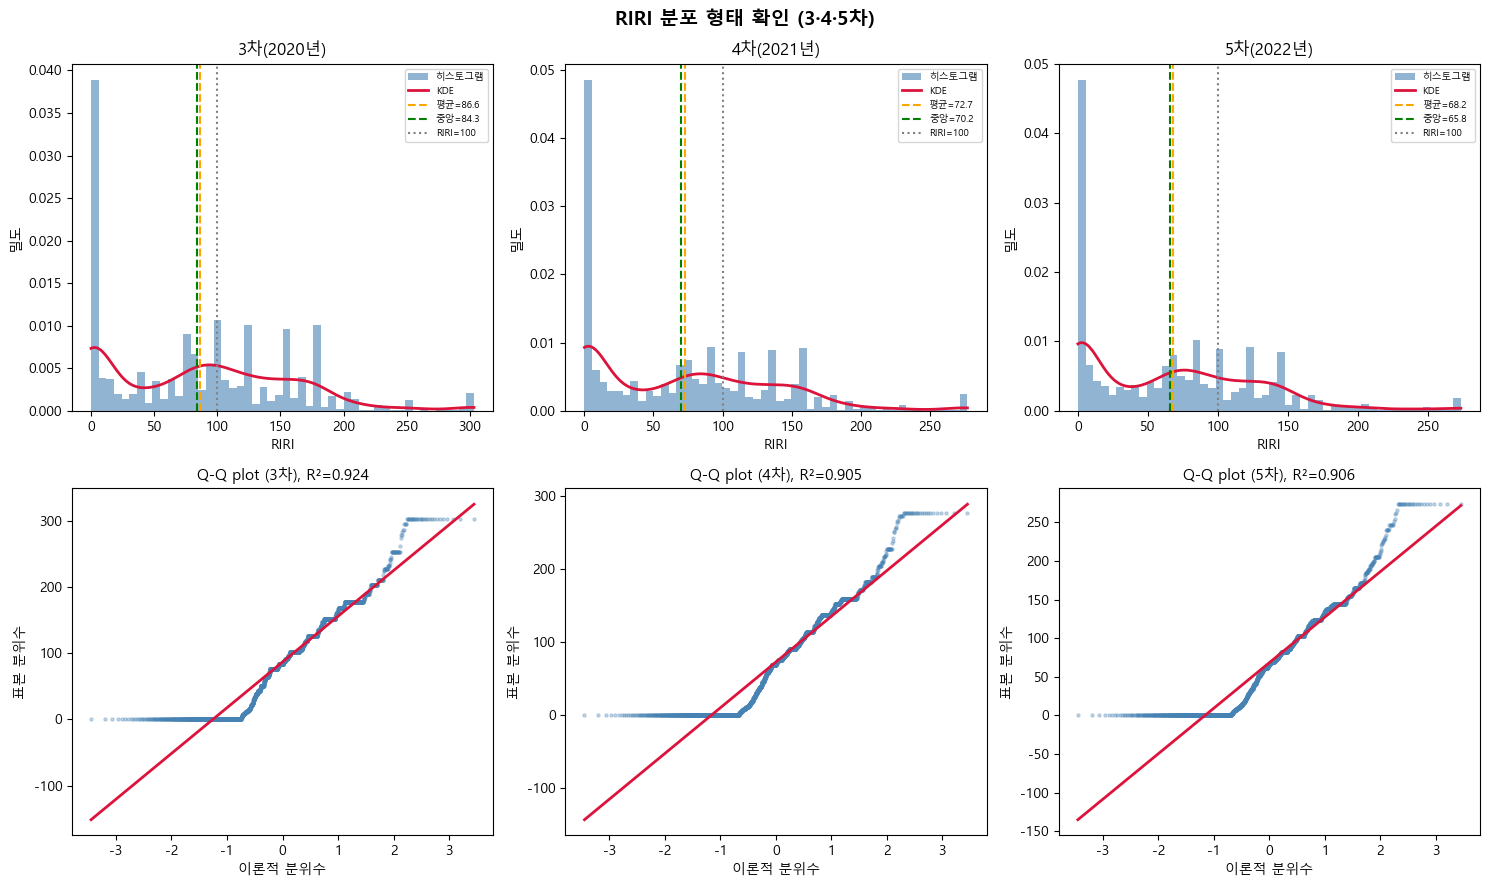

RIRI 정규성 검토

3차(2020년):
  왜도(skewness) = 0.512  
  첨도(kurtosis) = -0.228  
  Shapiro-Wilk: W=0.9239, p=0.0000 ← 정규성 기각
  → 로그변환 불필요

4차(2021년):
  왜도(skewness) = 0.649  
  첨도(kurtosis) = -0.120  
  Shapiro-Wilk: W=0.9047, p=0.0000 ← 정규성 기각
  → 로그변환 불필요

5차(2022년):
  왜도(skewness) = 0.745  
  첨도(kurtosis) = 0.238  
  Shapiro-Wilk: W=0.9050, p=0.0000 ← 정규성 기각
  → 로그변환 불필요


In [102]:
# ============================================================
# RIRI 분포 형태 확인
# 1) 히스토그램 + KDE
# 2) Q-Q plot (정규성 확인)
# 3) 기술통계 + 왜도/첨도
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('RIRI 분포 형태 확인 (3·4·5차)', fontsize=14, fontweight='bold')

for idx, (w, year) in enumerate([(3, 2020), (4, 2021), (5, 2022)]):
    col = f'RIRI_w{w}'
    s   = df_lcga[col].dropna()

    # ── 히스토그램 + KDE ──────────────────────────────────
    ax1 = axes[0][idx]
    ax1.hist(s, bins=50, density=True, alpha=0.6, color='steelblue', label='히스토그램')
    kde_x = np.linspace(s.min(), s.max(), 300)
    kde   = stats.gaussian_kde(s)
    ax1.plot(kde_x, kde(kde_x), color='crimson', linewidth=2, label='KDE')
    ax1.axvline(s.mean(),   color='orange', linestyle='--', linewidth=1.5, label=f'평균={s.mean():.1f}')
    ax1.axvline(s.median(), color='green',  linestyle='--', linewidth=1.5, label=f'중앙={s.median():.1f}')
    ax1.axvline(100, color='gray', linestyle=':', linewidth=1.5, label='RIRI=100')
    ax1.set_title(f'{w}차({year}년)', fontsize=12)
    ax1.set_xlabel('RIRI')
    ax1.set_ylabel('밀도')
    ax1.legend(fontsize=7)

    # ── Q-Q plot ──────────────────────────────────────────
    ax2 = axes[1][idx]
    (osm, osr), (slope, intercept, r) = stats.probplot(s, dist='norm')
    ax2.scatter(osm, osr, alpha=0.3, s=5, color='steelblue')
    ax2.plot(osm, slope * np.array(osm) + intercept, color='crimson', linewidth=2)
    ax2.set_title(f'Q-Q plot ({w}차), R²={r**2:.3f}', fontsize=11)
    ax2.set_xlabel('이론적 분위수')
    ax2.set_ylabel('표본 분위수')

plt.tight_layout()
plt.savefig('riri_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 왜도 · 첨도 출력 ──────────────────────────────────────
print("=" * 50)
print("RIRI 정규성 검토")
print("=" * 50)
for w, year in [(3, 2020), (4, 2021), (5, 2022)]:
    s = df_lcga[f'RIRI_w{w}'].dropna()
    skew = stats.skew(s)
    kurt = stats.kurtosis(s)
    stat_sw, p_sw = stats.shapiro(s.sample(min(5000, len(s)), random_state=42))
    print(f"\n{w}차({year}년):")
    print(f"  왜도(skewness) = {skew:.3f}  {'← 우편포(양의 왜도)' if skew > 1 else ''}")
    print(f"  첨도(kurtosis) = {kurt:.3f}  {'← 뾰족한 분포' if kurt > 3 else ''}")
    print(f"  Shapiro-Wilk: W={stat_sw:.4f}, p={p_sw:.4f} "
          f"{'← 정규성 기각' if p_sw < 0.05 else '← 정규성 기각 안됨'}")
    print(f"  → 로그변환 {'권장' if abs(skew) > 1 else '불필요'}")

- 0 근처의 급격한 스파이크.
    - 3, 4, 5차 모두 RIRI=0 부근에 밀도가 극도로 높음.
        - 취업을 아예 못한 패널, 즉 근로소득이 0인 사람들이 상당수 포함되어 있다는 뜻.
        - Q_irr(근로소득 비중)이 0이면 RIRI도 0.
- 50~150 구간에 완만한 두 번째 봉우리가 있음.
    - KDE 곡선이 쌍봉형(bimodal)에 가까운 형태.
    - 소득이 거의 없는 집단과 어느 정도 회복된 집단이 섞여있다는 구조적 신호.
        - LCGA가 이 두 집단을 자연스럽게 분리해줄수도?
- 시간이 지날 수록(3차->5차) 0 근처 스파이크가 더 뾰족해지고 전체 분포가 왼쪽으로 이동하는 것이 포착됨.
    - 미회복 집단이 고착화되고 있다는 기술통계 결과와 일치.

QQ plot에서 보이는 것
- R^2가 0.905~0.924로 높아보이긴 하지만, 플롯 모양이 정규분포에서 벗어나있음
- 계단 형태..
    - 분포가 **혼합 구조**라는 뜻

- 로그 변환 필요.
    - 단순 log 말고 log(RIRI + 1)형태로 변환, LCGA 투입
    - 0 스파이크의 영향 최소화, 모델 안정적으로 수렴
- LCGA 집단 수는 3~4개가 적절할 것으로 예상
    - BIC 기준 k=2,3,4,5 다 돌려보기

In [103]:
# ============================================================
# RIRI 로그변환: log(RIRI + 1)
# RIRI=0인 케이스 보존하면서 분포 정규화
# ============================================================

for w in [3, 4, 5]:
    col     = f'RIRI_w{w}'
    log_col = f'logRIRI_w{w}'
    df_lcga[log_col] = np.log1p(df_lcga[col])  # log(x+1)

# 변환 결과 확인
print("=" * 50)
print("로그변환 전후 비교")
print("=" * 50)

for w in [3, 4, 5]:
    orig = df_lcga[f'RIRI_w{w}'].dropna()
    log  = df_lcga[f'logRIRI_w{w}'].dropna()
    print(f"\n{w}차:")
    print(f"  원본  | 평균={orig.mean():.2f}, SD={orig.std():.2f}, "
          f"왜도={orig.skew():.3f}")
    print(f"  로그  | 평균={log.mean():.2f},  SD={log.std():.2f},  "
          f"왜도={log.skew():.3f}")

로그변환 전후 비교

3차:
  원본  | 평균=86.61, SD=71.84, 왜도=0.513
  로그  | 평균=3.48,  SD=2.01,  왜도=-0.967

4차:
  원본  | 평균=72.74, SD=65.90, 왜도=0.650
  로그  | 평균=3.23,  SD=2.02,  왜도=-0.758

5차:
  원본  | 평균=68.25, SD=61.92, 왜도=0.745
  로그  | 평균=3.20,  SD=1.98,  왜도=-0.785


In [104]:
from scipy.stats import yeojohnson, boxcox

print("=" * 55)
print("변환 방법별 왜도 비교")
print("=" * 55)

for w in [3, 4, 5]:
    col  = f'RIRI_w{w}'
    s    = df_lcga[col].dropna()

    # 원본
    skew_orig = s.skew()

    # log(x+1)
    skew_log  = np.log1p(s).skew()

    # sqrt
    skew_sqrt = np.sqrt(s).skew()

    # Yeo-Johnson (0, 음수 모두 처리 가능)
    yj, _ = yeojohnson(s)
    skew_yj = pd.Series(yj).skew()

    # Box-Cox (0 제외 필요 → 0을 0.001로 대체)
    s_bc = s.replace(0, 0.001)
    bc, _ = boxcox(s_bc)
    skew_bc = pd.Series(bc).skew()

    print(f"\n{w}차:")
    print(f"  원본        왜도 = {skew_orig:.3f}")
    print(f"  log(x+1)   왜도 = {skew_log:.3f}")
    print(f"  sqrt        왜도 = {skew_sqrt:.3f}")
    print(f"  Yeo-Johnson 왜도 = {skew_yj:.3f}")
    print(f"  Box-Cox     왜도 = {skew_bc:.3f}")
    print(f"  → 왜도 절댓값 최소: ", end="")
    results = {
        '원본': abs(skew_orig),
        'log':  abs(skew_log),
        'sqrt': abs(skew_sqrt),
        'YJ':   abs(skew_yj),
        'BC':   abs(skew_bc),
    }
    best = min(results, key=results.get)
    print(f"{best} ({results[best]:.3f})")

변환 방법별 왜도 비교

3차:
  원본        왜도 = 0.513
  log(x+1)   왜도 = -0.967
  sqrt        왜도 = -0.419
  Yeo-Johnson 왜도 = -0.454
  Box-Cox     왜도 = -0.859
  → 왜도 절댓값 최소: sqrt (0.419)

4차:
  원본        왜도 = 0.650
  log(x+1)   왜도 = -0.758
  sqrt        왜도 = -0.240
  Yeo-Johnson 왜도 = -0.373
  Box-Cox     왜도 = -0.740
  → 왜도 절댓값 최소: sqrt (0.240)

5차:
  원본        왜도 = 0.745
  log(x+1)   왜도 = -0.785
  sqrt        왜도 = -0.236
  Yeo-Johnson 왜도 = -0.365
  Box-Cox     왜도 = -0.752
  → 왜도 절댓값 최소: sqrt (0.236)


In [105]:
# sqrt 변환 적용
for w in [3, 4, 5]:
    col      = f'RIRI_w{w}'
    sqrt_col = f'sqrtRIRI_w{w}'
    df_lcga[sqrt_col] = np.sqrt(df_lcga[col])

# 확인
print("sqrt 변환 결과")
for w in [3, 4, 5]:
    s = df_lcga[f'sqrtRIRI_w{w}'].dropna()
    print(f"{w}차: 평균={s.mean():.2f}, SD={s.std():.2f}, 왜도={s.skew():.3f}")

sqrt 변환 결과
3차: 평균=7.80, SD=5.07, 왜도=-0.419
4차: 평균=6.96, SD=4.93, 왜도=-0.240
5차: 평균=6.77, SD=4.73, 왜도=-0.236


In [106]:
df_lcga.head(3)

,pid,p05,nonresponse05,workperiod14,accident,injurytype,injurypart,con16,acc1,hire1,...,lifesatis_w5,health_w5,job_rehab,soc_rehab,logRIRI_w3,logRIRI_w4,logRIRI_w5,sqrtRIRI_w3,sqrtRIRI_w4,sqrtRIRI_w5
1,2,1,NaN,10,2,13,1,6,2012,2008,...,1.0,1.0,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3,1,NaN,7,1,1,9,6,2014,2013,...,3.0,2.0,0.0,0.0,3.857421,4.306413,5.614808,6.807577,8.554178,16.536649
3,4,1,NaN,12,2,13,1,6,2015,2009,...,3.0,1.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


RIRI 변환 후 변수 이름: sqrtRIRI_w3/4/5

### 결측 패턴 확인

In [107]:
# ============================================================
# ① 결측 분포 - 차수별 결측 현황
# ============================================================

print("=" * 55)
print("① 결측 분포 (차수별)")
print("=" * 55)

riri_cols = ['RIRI_w3', 'RIRI_w4', 'RIRI_w5']
n = len(df_lcga)

for col in riri_cols:
    miss  = df_lcga[col].isna().sum()
    valid = df_lcga[col].notna().sum()
    print(f"  {col}: 유효={valid}({valid/n*100:.1f}%), 결측={miss}({miss/n*100:.1f}%)")

# 3차수 동시 결측 패턴
print(f"\n  3차수 모두 유효: {df_lcga[riri_cols].notna().all(axis=1).sum()}명")
print(f"  2차수 유효:      {(df_lcga[riri_cols].notna().sum(axis=1)==2).sum()}명")
print(f"  1차수만 유효:    {(df_lcga[riri_cols].notna().sum(axis=1)==1).sum()}명")


① 결측 분포 (차수별)
  RIRI_w3: 유효=2436(95.8%), 결측=106(4.2%)
  RIRI_w4: 유효=2482(97.6%), 결측=60(2.4%)
  RIRI_w5: 유효=2472(97.2%), 결측=70(2.8%)

  3차수 모두 유효: 2306명
  2차수 유효:      236명
  1차수만 유효:    0명


In [108]:
# ============================================================
# ② 결측 패턴 - 어떤 조합으로 빠졌는지
# ============================================================

print("\n" + "=" * 55)
print("② 결측 패턴 (조합별)")
print("=" * 55)

df_lcga['miss_w3'] = df_lcga['RIRI_w3'].isna().astype(int)
df_lcga['miss_w4'] = df_lcga['RIRI_w4'].isna().astype(int)
df_lcga['miss_w5'] = df_lcga['RIRI_w5'].isna().astype(int)

pattern = df_lcga.groupby(['miss_w3','miss_w4','miss_w5']).size().reset_index(name='n')
pattern['%'] = (pattern['n'] / n * 100).round(1)
pattern.columns = ['3차결측','4차결측','5차결측','n','%']
pattern['패턴'] = pattern.apply(
    lambda r: ''.join(['결측' if r[f'{w}차결측'] else '유효'
                       for w in [3,4,5]]), axis=1)
print(pattern[['패턴','n','%']].to_string(index=False))



② 결측 패턴 (조합별)
    패턴    n    %
유효유효유효 2306 90.7
유효유효결측   70  2.8
유효결측유효   60  2.4
결측유효유효  106  4.2


In [109]:
# ============================================================
# ③ 결측 vs 비결측 집단 비교 (MCAR 검토)
#    각 차수별로 결측 여부에 따라 주요 변수 차이 검정
# ============================================================

print("\n" + "=" * 55)
print("③ 결측 vs 비결측 집단 비교")
print("=" * 55)

compare_vars = {
    'gender':    '성별(1=남,2=여)',
    'age054':    '연령대',
    'disa_class':'장해등급(0~2)',
    'RIRI_w3':   'RIRI_3차',
    'RIRI_w4':   'RIRI_4차',
}

for wave, miss_col in [(4, 'miss_w4'), (5, 'miss_w5')]:
    print(f"\n  [RIRI_{wave}차 결측 여부에 따른 집단 비교]")
    print(f"  {'변수':<15} {'비결측 평균':>10} {'결측 평균':>10} {'p-value':>10} {'판정':>10}")
    print("  " + "-" * 55)

    miss_idx    = df_lcga[miss_col] == 1
    nonmiss_idx = df_lcga[miss_col] == 0

    for var, label in compare_vars.items():
        if var not in df_lcga.columns:
            continue
        g0 = df_lcga.loc[nonmiss_idx, var].dropna()
        g1 = df_lcga.loc[miss_idx,    var].dropna()

        if len(g1) < 2:
            continue

        # 연속형: t-test / 범주형도 평균 비교로 간이 검정
        t, p = stats.ttest_ind(g0, g1, equal_var=False)
        sig  = '*** 유의' if p < 0.001 else ('** 유의' if p < 0.01
               else ('* 유의' if p < 0.05 else '비유의'))
        print(f"  {label:<15} {g0.mean():>10.3f} {g1.mean():>10.3f} "
              f"{p:>10.4f} {sig:>10}")

# Little's MCAR Test 대용: 전체 결측 패턴과 공변량 간 카이제곱
print("\n" + "=" * 55)
print("  [결측 여부와 장해등급 카이제곱 검정]")
print("=" * 55)

for wave, miss_col in [(4, 'miss_w4'), (5, 'miss_w5')]:
    ct = pd.crosstab(df_lcga['disa_class'], df_lcga[miss_col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"  RIRI_{wave}차 결측 × 장해등급: χ²={chi2:.3f}, df={dof}, p={p:.4f} "
          f"{'← 체계적 결측 의심' if p < 0.05 else '← MCAR 지지'}")

for wave, miss_col in [(4, 'miss_w4'), (5, 'miss_w5')]:
    ct = pd.crosstab(df_lcga['age054'], df_lcga[miss_col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"  RIRI_{wave}차 결측 × 연령대:   χ²={chi2:.3f}, df={dof}, p={p:.4f} "
          f"{'← 체계적 결측 의심' if p < 0.05 else '← MCAR 지지'}")

# 임시 컬럼 정리
df_lcga.drop(columns=['miss_w3','miss_w4','miss_w5'], inplace=True)


③ 결측 vs 비결측 집단 비교

  [RIRI_4차 결측 여부에 따른 집단 비교]
  변수                  비결측 평균      결측 평균    p-value         판정
  -------------------------------------------------------
  성별(1=남,2=여)          1.170      1.233     0.2621        비유의
  연령대                  3.161      3.000     0.2257        비유의
  장해등급(0~2)            1.516      1.450     0.5736        비유의
  RIRI_3차             86.576     88.143     0.8449        비유의

  [RIRI_5차 결측 여부에 따른 집단 비교]
  변수                  비결측 평균      결측 평균    p-value         판정
  -------------------------------------------------------
  성별(1=남,2=여)          1.170      1.229     0.2581        비유의
  연령대                  3.163      2.971     0.1364        비유의
  장해등급(0~2)            1.523      1.200     0.0001     *** 유의
  RIRI_3차             88.048     38.176     0.0000     *** 유의
  RIRI_4차             73.920     31.990     0.0000     *** 유의

  [결측 여부와 장해등급 카이제곱 검정]
  RIRI_4차 결측 × 장해등급: χ²=6.745, df=2, p=0.0343 ← 체계적 결측 의심
  RIRI_5차 결측 × 장해등급: χ²=141.456, df=2, p=0

- 결측률: LCGA에서 Full Information Maximum Likelihood(FIML)로 처리하면 됨.
- 결측 패턴도 괜찮
- **결측 vs 비결측 비교**
    - 4차 결측: 성별·연령·장해등급·RIRI 모두 비유의로, MCAR에 가까움
    - 5차 결측: 장해등급에서 결측 집단 평균이 1.200으로 비결측(1.523)보다 낮아요. 
        - 즉 무장해 또는 경증 집단이 5차에서 더 많이 빠졌어요. χ²=141.5, p<.001로 매우 강한 연관이에요.
        -  RIRI에서도 결측 집단의 3차 RIRI가 38.2, 4차가 32.0으로 비결측(88.0, 73.9)의 절반도 안 돼요.  
            - 소득회복이 낮은 사람들이 5차 조사에서 체계적으로 탈락하고 있어요.

MAR(Missing At Random)에 해당
- 완전 무작위(MCAR)는 아니지만, 결측이 관측된 변수(장해등급, 이전 차수 RIRI)로 설명이 되는 구조. 
    - 관측되지 않은 미지의 요인 때문이 아니라는 것.

[분석에 미치는 영향]
- 첫째, LCGA에서 FIML 추정을 쓰면 MAR 가정 하에 편향 없이 추정할 수 있어요. 별도 대체 작업 없이 진행해도 돼요.
- 둘째, 논문 한계점에 "5차 결측이 저소득·경증 집단에서 체계적으로 발생해 만성취약형 집단의 규모가 과소추정될 수 있다" 고 명시해야 해요. 탈락한 사람들이 바로 가장 회복이 안 된 집단이니까요.

In [110]:
# ============================================================
# 결측 처리 - FIML 방식
# LCGA 자체가 FIML로 결측 처리하므로
# 여기서는 결측 플래그 변수만 생성해두고
# 실제 대체는 하지 않음 (원본 유지)
# ============================================================

print("=" * 55)
print("결측 처리 - FIML 방식 확정")
print("=" * 55)

# 결측 플래그 변수 생성 (나중에 민감도 분석용)
for w in [3, 4, 5]:
    df_lcga[f'miss_flag_w{w}'] = df_lcga[f'RIRI_w{w}'].isna().astype(int)

# 완전 관측 케이스 수 확인
complete = df_lcga[['RIRI_w3','RIRI_w4','RIRI_w5']].notna().all(axis=1)
print(f"\n  완전 관측 케이스:  {complete.sum()}명 ({complete.mean()*100:.1f}%)")
print(f"  부분 결측 케이스:  {(~complete).sum()}명 ({(~complete).mean()*100:.1f}%)")
print(f"\n  → LCGA에서 FIML로 자동 처리 예정")
print(f"  → 원본 RIRI 값 유지 (별도 대체 없음)")

결측 처리 - FIML 방식 확정

  완전 관측 케이스:  2306명 (90.7%)
  부분 결측 케이스:  236명 (9.3%)

  → LCGA에서 FIML로 자동 처리 예정
  → 원본 RIRI 값 유지 (별도 대체 없음)



스파게티 플롯


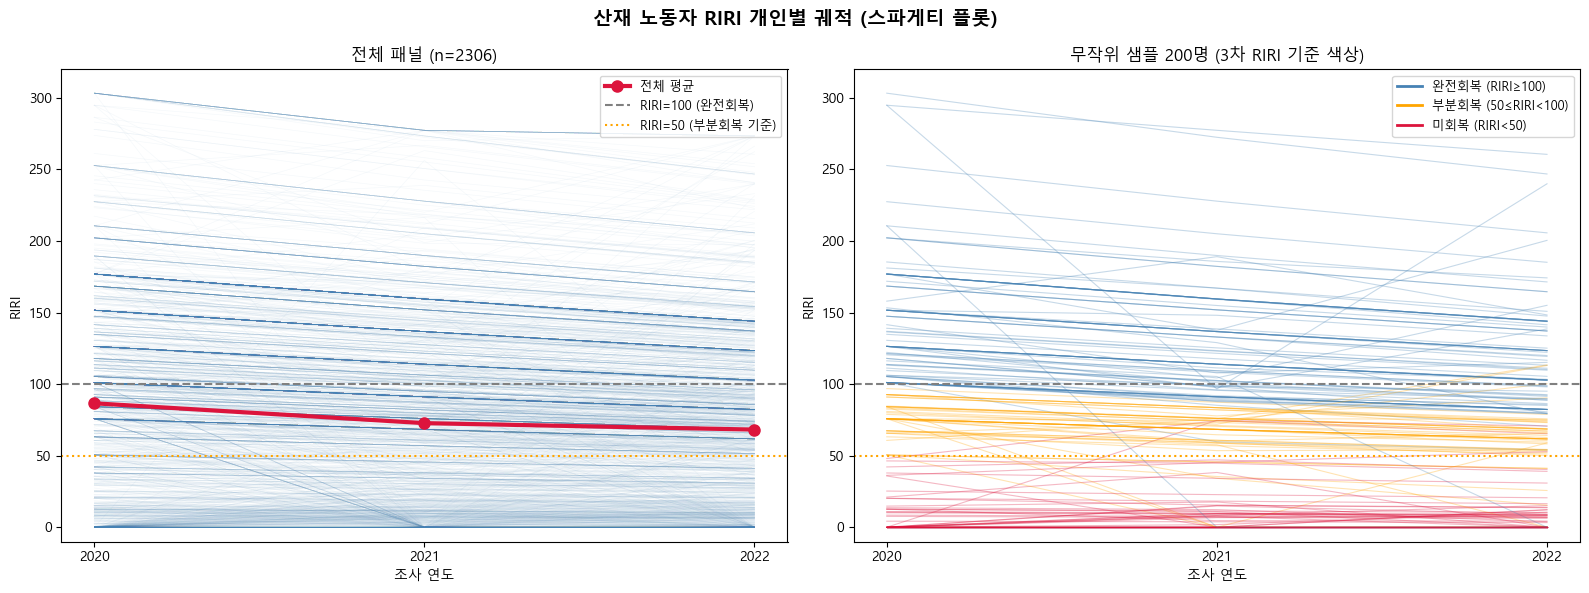

spaghetti_plot.png 저장 완료


In [111]:
# ============================================================
# 스파게티 플롯
# 개인별 RIRI 궤적 시각화
# 전체 + 무작위 샘플 100명
# ============================================================

print("\n" + "=" * 55)
print("스파게티 플롯")
print("=" * 55)

waves      = [3, 4, 5]
wave_years = [2020, 2021, 2022]
riri_cols  = ['RIRI_w3', 'RIRI_w4', 'RIRI_w5']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('산재 노동자 RIRI 개인별 궤적 (스파게티 플롯)', fontsize=14, fontweight='bold')

# ── 왼쪽: 전체 패널 (투명도 낮게) ──────────────────────────
ax1 = axes[0]
for _, row in df_lcga.iterrows():
    vals = [row[c] for c in riri_cols]
    if any(pd.isna(v) for v in vals):
        continue
    ax1.plot(wave_years, vals, color='steelblue', alpha=0.05, linewidth=0.5)

# 전체 평균 궤적 추가
means = [df_lcga[c].mean() for c in riri_cols]
ax1.plot(wave_years, means, color='crimson', linewidth=3,
         marker='o', markersize=8, label=f'전체 평균')
ax1.axhline(100, color='gray', linestyle='--', linewidth=1.5, label='RIRI=100 (완전회복)')
ax1.axhline(50,  color='orange', linestyle=':', linewidth=1.5, label='RIRI=50 (부분회복 기준)')
ax1.set_title(f'전체 패널 (n={complete.sum()})', fontsize=12)
ax1.set_xlabel('조사 연도')
ax1.set_ylabel('RIRI')
ax1.set_xticks(wave_years)
ax1.legend(fontsize=9)
ax1.set_ylim(-10, 320)

# ── 오른쪽: 무작위 샘플 200명 (궤적 패턴 파악용) ────────────
ax2 = axes[1]
complete_idx = df_lcga[df_lcga[riri_cols].notna().all(axis=1)].index
sample_idx   = np.random.RandomState(42).choice(complete_idx, size=min(200, len(complete_idx)), replace=False)
df_sample    = df_lcga.loc[sample_idx]

# RIRI 수준별 색상 구분 (3차 기준)
for _, row in df_sample.iterrows():
    vals  = [row[c] for c in riri_cols]
    riri3 = row['RIRI_w3']
    if riri3 >= 100:
        color = 'steelblue'    # 완전회복
    elif riri3 >= 50:
        color = 'orange'       # 부분회복
    else:
        color = 'crimson'      # 미회복
    ax2.plot(wave_years, vals, color=color, alpha=0.3, linewidth=0.8)

# 범례용 더미 라인
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color='steelblue', linewidth=2, label='완전회복 (RIRI≥100)'),
    Line2D([0],[0], color='orange',    linewidth=2, label='부분회복 (50≤RIRI<100)'),
    Line2D([0],[0], color='crimson',   linewidth=2, label='미회복 (RIRI<50)'),
]
ax2.axhline(100, color='gray',   linestyle='--', linewidth=1.5)
ax2.axhline(50,  color='orange', linestyle=':',  linewidth=1.5)
ax2.set_title('무작위 샘플 200명 (3차 RIRI 기준 색상)', fontsize=12)
ax2.set_xlabel('조사 연도')
ax2.set_ylabel('RIRI')
ax2.set_xticks(wave_years)
ax2.legend(handles=legend_elements, fontsize=9)
ax2.set_ylim(-10, 320)

plt.tight_layout()
plt.savefig('spaghetti_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("spaghetti_plot.png 저장 완료")

In [112]:
# ============================================================
# 궤적 유형 사전 파악
# 3차 → 5차 변화량 기준 집단 분포
# ============================================================

print("\n" + "=" * 55)
print("궤적 변화 방향 사전 파악")
print("=" * 55)

df_comp = df_lcga[df_lcga[riri_cols].notna().all(axis=1)].copy()
df_comp['delta_35'] = df_comp['RIRI_w5'] - df_comp['RIRI_w3']  # 3→5차 변화량

# 변화 방향 분류
df_comp['traj_type'] = pd.cut(
    df_comp['delta_35'],
    bins  = [-np.inf, -20, 20, np.inf],
    labels= ['하락형(△<-20)', '안정형(-20≤△≤20)', '상승형(△>20)']
)

dist = df_comp['traj_type'].value_counts()
for k, v in dist.items():
    print(f"  {k}: {v}명({v/len(df_comp)*100:.1f}%)")

print(f"\n  3→5차 평균 변화량: {df_comp['delta_35'].mean():.1f}")
print(f"  3→5차 변화량 SD:   {df_comp['delta_35'].std():.1f}")


궤적 변화 방향 사전 파악
  안정형(-20≤△≤20): 1222명(53.0%)
  하락형(△<-20): 980명(42.5%)
  상승형(△>20): 104명(4.5%)

  3→5차 평균 변화량: -16.5
  3→5차 변화량 SD:   30.1


### Spaghetti Plot 해석

핵심 질문: "산재 노동자들의 소득은 시간이 지나면서 어떻게 됐나?"

- RIRI: 생활임금 대비 내가 버는 돈의 비율.
    - RIRI=100이면 생활임금만큼 벌고 있다는 뜻.
    - RIRI=50이면 생활임금의 절반만 번다는 뜻.

##### 왼쪽 그래프: 전체 2,306명
- 빨간 굵은 선: 전체 평균
    - 2020년 86.6 → 2021년 72.7 → 2022년 68.2
    - 산재 노동자 현황이 시간이 지날수록 조금씩 나빠진다
- 상단 100~300 사이를 수평으로 달리는 선
    - 처음부터 생활임금 이상을 벌었고 5년 내내 유지한 사람들
- 하단 0 근처의 선
    - 처음부터 거의 소득이 없었고 5년이 지나도 그대로.


평균 86.6이라는 숫자는 "100 이상인 사람"과 "0에 가까운 사람"을 섞어서 나온 숫자라 현실을 제대로 반영 못함.

= 연구계획서에서 언급한 *"평균의 함정"*

##### 오른쪽 그래프: 200명 샘플
- **파란선**: 완전회복 집단 (RIRI ≥ 100)
    - 2020년부터 생활임금 이상을 벌었어요. 
    - 시간이 지나면서 조금씩 내려가긴 하지만 대부분 100 근처를 유지
    - 이 집단은 산재를 당했어도 경제적으로 안정적으로 복귀한 사람들
- **주황선**: 부분회복 집단 (RIRI 50~100)
    - 생활임금의 절반~전부 수준을 벌고 있어요. 
    - 완전히 회복은 못 했지만 그렇다고 아주 바닥은 아닌 중간 집단
    - 시간이 지나면서 일부는 50 아래로 떨어지기도. 
    - 불안정한 집단
- [주목 필요] **빨간선**: 미회복 집단 (RIRI < 50)
    - 2020년부터 생활임금의 절반도 못 벌었고, 2022년에도 거의 그대로예요. 0에 아주 가까운 선들이 많음. 
    - 사실상 소득이 없는 상태가 5년째 지속되고 있는 것.
    - 만성적으로 경제적 어려움에 고착된 집단

##### 수치적 변화
3→5차 변화량을 보면:

- 안정형(변화 거의 없음): 1,222명, 53%
- 하락형(20 이상 떨어짐): 980명, 42.5%
- 상승형(20 이상 올라감): 104명, 4.5%

평균 변화량이 -16.5.
- 전체적으로 조금씩 나빠지고 있는 것.
- 상승형이 4.5%밖에 안 된다는 게 문제.
- 100명 중 4~5명만 시간이 지나면서 더 나아졌고, 나머지 95명은 제자리이거나 더 나빠짐

##### 요약
산재 노동자의 절반은 처음부터 회복이 됐든 안 됐든 그 상태로 고착되고, 42%는 시간이 지날수록 더 나빠지고 있음. 더 좋아지는 사람은 5%도 안 됨.


= LCGA 해야하는 이유. 평균으로는 이 세 집단을 나누기가 힘듦.

### 변수 간 상관관계

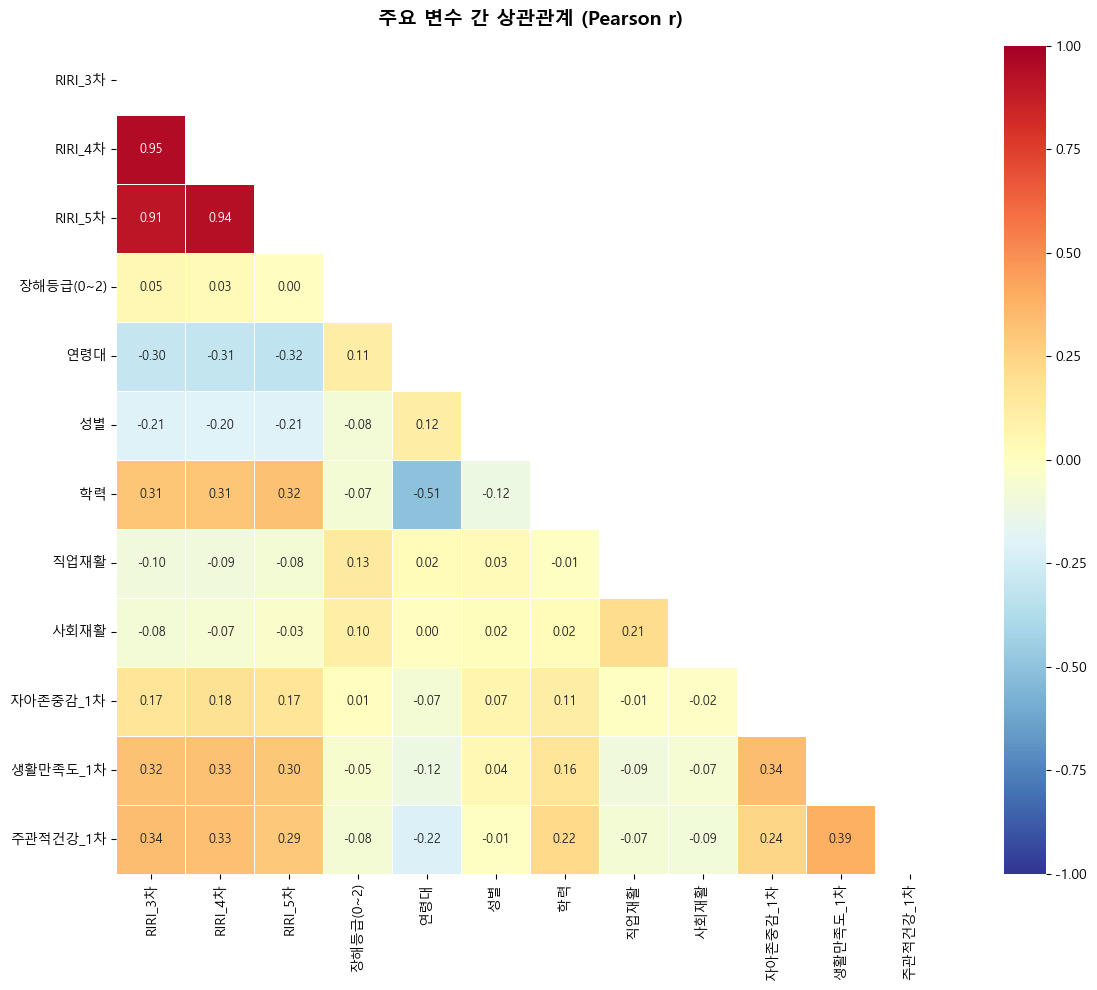

RIRI_3차와 각 변수 간 상관계수 (절댓값 순)
  RIRI_4차        : r= 0.948, p=0.0000 ***
  RIRI_5차        : r= 0.909, p=0.0000 ***
  주관적건강_1차       : r= 0.342, p=0.0000 ***
  생활만족도_1차       : r= 0.324, p=0.0000 ***
  학력             : r= 0.306, p=0.0000 ***
  연령대            : r=-0.303, p=0.0000 ***
  성별             : r=-0.209, p=0.0000 ***
  자아존중감_1차       : r= 0.170, p=0.0000 ***
  직업재활           : r=-0.100, p=0.0000 ***
  사회재활           : r=-0.078, p=0.0001 ***
  장해등급(0~2)      : r= 0.045, p=0.0258 *

RIRI 차수 간 상관 (시계열 안정성)
  RIRI_3차 vs RIRI_4차: r=0.948, p=0.0000
  RIRI_4차 vs RIRI_5차: r=0.937, p=0.0000
  RIRI_3차 vs RIRI_5차: r=0.909, p=0.0000


In [113]:
import seaborn as sns

# ============================================================
# ④ 변수 간 상관관계
# RIRI와 주요 공변량 간 관계 파악
# ============================================================

# 분석에 쓸 변수 선택
corr_vars = {
    'RIRI_w3':    'RIRI_3차',
    'RIRI_w4':    'RIRI_4차',
    'RIRI_w5':    'RIRI_5차',
    'disa_class': '장해등급(0~2)',
    'age054':     '연령대',
    'gender':     '성별',
    'edu05':      '학력',
    'job_rehab':  '직업재활',
    'soc_rehab':  '사회재활',
    'esteem_w1':  '자아존중감_1차',
    'lifesatis_w1':'생활만족도_1차',
    'health_w1':  '주관적건강_1차',
}

# 실제 있는 컬럼만
exist_vars = {k: v for k, v in corr_vars.items() if k in df_lcga.columns}
df_corr = df_lcga[list(exist_vars.keys())].copy()
df_corr.columns = list(exist_vars.values())

# ── 상관계수 행렬 계산 ────────────────────────────────────
corr_matrix = df_corr.corr(method='pearson')

# ── 히트맵 ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # 상삼각 마스킹

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9},
)
ax.set_title('주요 변수 간 상관관계 (Pearson r)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── RIRI_3차 기준 상관계수 순위 출력 ─────────────────────
print("=" * 55)
print("RIRI_3차와 각 변수 간 상관계수 (절댓값 순)")
print("=" * 55)

riri3_corr = corr_matrix['RIRI_3차'].drop('RIRI_3차').abs().sort_values(ascending=False)
for var, r in riri3_corr.items():
    orig_r = corr_matrix['RIRI_3차'][var]
    # 유의성 검정
    n_valid = df_corr[['RIRI_3차', var]].dropna().__len__()
    t_stat  = orig_r * np.sqrt(n_valid - 2) / np.sqrt(1 - orig_r**2)
    p_val   = 2 * (1 - stats.t.cdf(abs(t_stat), df=n_valid - 2))
    sig     = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
    print(f"  {var:<15}: r={orig_r:>6.3f}, p={p_val:.4f} {sig}")

# ── RIRI 차수 간 상관 (시계열 안정성) ────────────────────
print("\n" + "=" * 55)
print("RIRI 차수 간 상관 (시계열 안정성)")
print("=" * 55)
for (w1, w2) in [(3,4),(4,5),(3,5)]:
    c1, c2 = f'RIRI_w{w1}', f'RIRI_w{w2}'
    both   = df_lcga[[c1,c2]].dropna()
    r, p   = stats.pearsonr(both[c1], both[c2])
    print(f"  RIRI_{w1}차 vs RIRI_{w2}차: r={r:.3f}, p={p:.4f}")

- **r=0.95**에 가깝다는 건 3차에 RIRI가 높았던 사람은 4차, 5차에도 높고 / 낮았던 사람은 계속 낮다는 뜻.
    - 쉽게 말하면 **"한번 고착되면 안 바뀐다"** 는 거. 
    - 스파게티 플롯에서 선들이 교차 없이 거의 평행하게 흘렀던 게 이 숫자로 증명됨.

- **집단 간 경계가 뚜렷할 가능성**이 높아요.
    - 궤적이 섞이지 않고 각자 레인을 유지하니까 LCGA가 집단을 깔끔하게 분리할 가능성이 높아요.
- 기울기(slope)보다 **절편(intercept)**이 집단을 더 잘 구분할 것
    - 즉 "얼마나 변하냐"보다 **"어느 수준에서 시작했냐"** 가 집단을 결정하는 핵심 요인

- **심리·건강 변수**가 예상보다 강해요.
    - 주관적건강(r=0.342), 생활만족도(r=0.324)가 학력(r=0.306)보다 높게 나옴. 
    - 신체적·심리적 상태가 소득회복과 밀접하게 연결돼 있다는 것. 
    - 연구계획서에서 "심리 지원의 경제적 가치"를 주장한 근거가 여기서 나옴.
- **재활서비스** 상관이 음수(-0.100, -0.078)예요.
    - 재활서비스를 이용할수록 RIRI가 낮다는 건데, 이건 인과관계가 아니라 **선택편향** 이에요. 
    - 소득이 낮고 회복이 안 된 사람들이 재활서비스를 더 많이 이용하는 것. 
    - 나중에 BCH 분석에서 이 부분을 통제해야 함.
- **장해등급** 상관이 가장 낮아요(r=0.045).
    - 경증이 많은 표본 구조 때문에 변별력이 떨어진 것
    - 단순 상관으로는 잘 안 잡히지만 LCGA 집단 내에서는 의미 있게 나올 수도..

In [114]:
df_lcga.to_csv('pswci_riri_lcga.csv')

In [115]:
# ============================================================
# 1. R 결과 로드 및 병합
# ============================================================

# R에서 저장한 집단 할당 결과
df_class = pd.read_csv('lcga_class_k4.csv')
print("집단 할당 데이터:", df_class.shape)
print(df_class.head())
print("\n집단별 인원:")
print(df_class['class'].value_counts().sort_index())

# 기존 df_lcga에 집단 병합
df_lcga = df_lcga.drop(columns=['class'], errors='ignore')
df_lcga = df_lcga.merge(df_class[['pid','class']], on='pid', how='left')
df_lcga = df_lcga.rename(columns={'class': 'lcga_class'})

# 집단 레이블 부여
class_label = {
    1: '만성미회복형',
    2: '하락취약형',
    3: '부분회복형',
    4: '안정고소득형'
}
df_lcga['class_label'] = df_lcga['lcga_class'].map(class_label)

print("\n집단 레이블 확인:")
print(df_lcga['class_label'].value_counts())


집단 할당 데이터: (2542, 6)
   pid  class         prob1         prob2         prob3         prob4
0    2      1  9.999981e-01  1.928174e-06  1.558484e-20  1.284030e-38
1    3      3  3.742694e-23  1.356611e-09  8.745858e-01  1.254142e-01
2    4      1  9.999981e-01  1.928174e-06  1.558484e-20  1.284030e-38
3    5      1  9.999763e-01  2.369664e-05  1.235853e-14  3.630346e-27
4    6      1  9.999981e-01  1.928174e-06  1.558484e-20  1.284030e-38

집단별 인원:
class
1    702
2    352
3    897
4    591
Name: count, dtype: int64

집단 레이블 확인:
class_label
부분회복형     897
만성미회복형    702
안정고소득형    591
하락취약형     352
Name: count, dtype: int64


In [116]:
# ============================================================
# 2. 집단별 공변량 분포 비교 (BCH 전 기술통계)
#    성별, 연령, 학력, 장해등급, 재활서비스, 심리변수
# ============================================================

print("\n" + "=" * 60)
print("집단별 공변량 분포 비교")
print("=" * 60)

# 연속형 변수: 집단별 평균 비교 + 일원분산분석(ANOVA)
cont_vars = {
    'age054':     '연령대',
    'edu05':      '학력',
    'disa_class': '장해등급',
    'esteem_w1':  '자아존중감_1차',
    'lifesatis_w1':'생활만족도_1차',
    'G01005001':  '주관적건강_1차',
}

print("\n[연속형 변수 집단별 평균 및 ANOVA]")
print(f"{'변수':<15} {'집단1':>8} {'집단2':>8} {'집단3':>8} {'집단4':>8} {'F':>8} {'p':>8}")
print("-" * 65)

for col, label in cont_vars.items():
    if col not in df_lcga.columns:
        continue
    groups = [df_lcga[df_lcga['lcga_class']==k][col].dropna()
              for k in [1,2,3,4]]
    means  = [g.mean() for g in groups]
    f, p   = stats.f_oneway(*groups)
    sig    = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else ''))
    print(f"{label:<15} "
          f"{means[0]:>8.2f} {means[1]:>8.2f} "
          f"{means[2]:>8.2f} {means[3]:>8.2f} "
          f"{f:>8.2f} {p:>7.4f}{sig}")

# 범주형 변수: 카이제곱 검정
cat_vars = {
    'gender':     '성별',
    'job_rehab':  '직업재활',
    'soc_rehab':  '사회재활',
}

print("\n[범주형 변수 집단별 분포 및 카이제곱]")
for col, label in cat_vars.items():
    if col not in df_lcga.columns:
        continue
    ct = pd.crosstab(df_lcga['lcga_class'], df_lcga[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else ''))
    print(f"\n  {label}: χ²={chi2:.3f}, df={dof}, p={p:.4f} {sig}")
    # 집단별 비율
    pct = ct.div(ct.sum(axis=1), axis=0).round(3) * 100
    print(pct.to_string())



집단별 공변량 분포 비교

[연속형 변수 집단별 평균 및 ANOVA]
변수                   집단1      집단2      집단3      집단4        F        p
-----------------------------------------------------------------
연령대                 3.54     3.35     3.05     2.74    84.35  0.0000***
학력                  3.17     3.41     3.75     4.01    87.00  0.0000***
장해등급                1.48     1.51     1.50     1.57     1.45  0.2272
자아존중감_1차            2.49     2.65     2.77     2.86    32.84  0.0000***
생활만족도_1차            2.87     3.16     3.30     3.51   100.56  0.0000***
주관적건강_1차            2.08     2.49     2.66     2.74   149.18  0.0000***

[범주형 변수 집단별 분포 및 카이제곱]

  성별: χ²=127.739, df=3, p=0.0000 ***
gender         1     2
lcga_class            
1           78.6  21.4
2           73.9  26.1
3           79.7  20.3
4           97.8   2.2

  직업재활: χ²=25.125, df=3, p=0.0000 ***
job_rehab    0.0   1.0
lcga_class            
1           82.2  17.8
2           77.8  22.2
3           85.5  14.5
4           89.2  10.8

  사회재활: χ²=10.889

In [117]:
# ============================================================
# 3. 다항 로지스틱 회귀 (BCH 근사)
#    집단을 종속변수, 공변량을 독립변수로
#    Reference: 집단3 (부분회복형, 가장 큰 집단)
# ============================================================

print("\n" + "=" * 60)
print("다항 로지스틱 회귀 (결정요인 분석)")
print("=" * 60)

from statsmodels.discrete.discrete_model import MNLogit
import statsmodels.api as sm

# 분석 변수 설정
pred_vars = [
    'gender', 'age054', 'edu05', 'disa_class',
    'job_rehab', 'soc_rehab',
    'esteem_w1', 'lifesatis_w1', 'G01005001'
]

exist_pred = [v for v in pred_vars if v in df_lcga.columns]

# 결측 제거
df_mnl = df_lcga[['lcga_class'] + exist_pred].dropna()
print(f"\n분석 대상: {len(df_mnl)}명")

# Reference 집단: 3 (부분회복형)
# statsmodels MNLogit은 0부터 시작하므로 재코딩
class_map = {1: 0, 2: 1, 3: 2, 4: 3}  # 3→2(reference)
df_mnl['y'] = df_mnl['lcga_class'].map(class_map)

X = sm.add_constant(df_mnl[exist_pred])
y = df_mnl['y']

model = MNLogit(y, X)
result = model.fit(method='bfgs', maxiter=500, disp=False)

print("\n[다항 로지스틱 회귀 결과 요약]")
print(result.summary())



다항 로지스틱 회귀 (결정요인 분석)

분석 대상: 2542명

[다항 로지스틱 회귀 결과 요약]
                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                 2542
Model:                        MNLogit   Df Residuals:                     2512
Method:                           MLE   Df Model:                           27
Date:                Sat, 21 Mar 2026   Pseudo R-squ.:                  0.1362
Time:                        21:12:45   Log-Likelihood:                -2933.4
converged:                       True   LL-Null:                       -3395.8
Covariance Type:            nonrobust   LLR p-value:                1.806e-177
         y=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -3.5783      0.630     -5.677      0.000      -4.814      -2.343
gender           0.2090      0.161      1.302      0.193      -0.106 

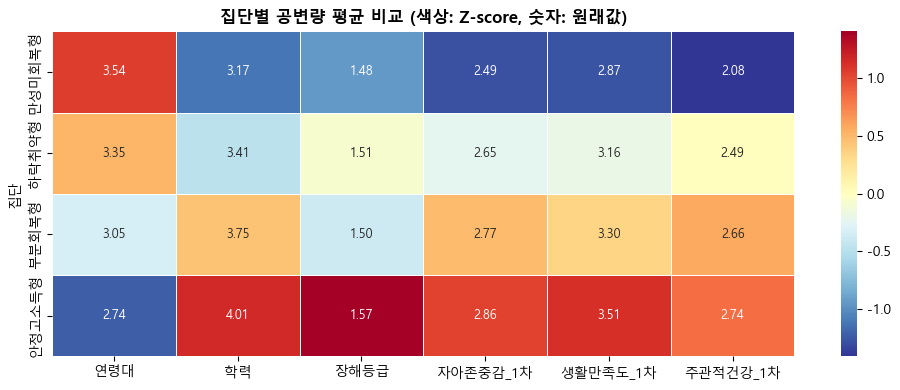

class_covariate_heatmap.png 저장 완료


In [118]:
# ============================================================
# 4. 집단별 공변량 분포 히트맵 시각화
# ============================================================

# 집단별 평균 정규화 (Z-score)
heatmap_vars = list(cont_vars.keys())
heatmap_vars = [v for v in heatmap_vars if v in df_lcga.columns]

heatmap_data = []
for k in [1, 2, 3, 4]:
    row = {'집단': class_label[k]}
    for col in heatmap_vars:
        row[cont_vars[col]] = df_lcga[df_lcga['lcga_class']==k][col].mean()
    heatmap_data.append(row)

df_heat = pd.DataFrame(heatmap_data).set_index('집단')

# Z-score 정규화
df_heat_z = (df_heat - df_heat.mean()) / df_heat.std()

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    df_heat_z,
    annot=df_heat.round(2),
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('집단별 공변량 평균 비교 (색상: Z-score, 숫자: 원래값)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('class_covariate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("class_covariate_heatmap.png 저장 완료")

### 결과 해석

**집단별 공변량 분포 비교**
- 집단1 → 집단4로 갈수록 **젊고, 학력 높고, 심리·건강 상태가 좋음**. 
- 장해등급은 집단 간 차이가 없음 (p=0.227). 
    - *장해 경중이 소득회복을 결정하지 않는다*는 뜻. 
    - 연구계획서의 "경증 장해임에도 소득이 회복 안 되는 정책 사각지대" 주장을 뒷받침.
- **성별**은 집단4에서 두드러짐. 
    - 집단4는 남성이 97.8%인데 집단1~3은 73~79% 수준이에요. 
    - 안정고소득형에 여성이 거의 없다는 건 *성별 격차가 회복 궤적에 영향을 준다*는 것.


**다항 로지스틱 회귀 결과**

Reference 집단: 집단3(부분회복형)과 그 외 집단

- y=1: 만성미회복 vs 부분회복
    - *연령* 높을수록 만성미회복형 가능성 ↑
    - *만족도* 낮을수록 만성미회복형
    - *건강* 나쁠수록 만성미회복형
    - *직업재활* 이용자가 만성미회복형에 더 많음 (선택편향)
    - 자아존중감, 성별, 학력, 장해등급은 유의하지 않음
- y=2: 하락취약형 vs 부분회복형
    - *연령* 높을수록 하락취약형 가능성 ↑
    - *만족도* 낮을수록 하락취약형
    - *건강* 나쁠수록 하락취약형
    - ***학력*** 낮을수록 하락취약형
    - ***장해*** 경미할수록 하락취약형 (역설적)
    - ***자아존중감*** 낮을수록 하락취약형
    - 경증 장해일수록 하락취약형에 속한다는 건, *장해가 심하지 않아도 시간이 지날수록 소득이 떨어지는 집단이 존재한다*는 것.
- y=3: 안정고소득형 vs 부분회복형
    - *연령* 높을수록 안정고소득형 가능성 낮음
    - *만족도* 높을수록 안정고소득형
    - *건강* 좋을수록 안정고소득형
    - *학력* 높을수록 안정고소득형
    - *경증*일수록 안정고소득형
    - *여성*일수록 안정고소득형 가능성 극히 **낮음**
        - 성별 효과가 압도적
        - 여성은 남성 대비 안정고소득형에 속할 확률이 92% 낮음
    - *자아존중감* 높을수록 안정고소득형
    - *산재 후 경제적 완전회복에서 성별 격차가 극단적으로 크다*는 것.

**전체 요약**
- 공통 유의 변수
    - 연령대
        - 나이 많을수록 회복 어려움
    - 주관적건강
        - 건강이 회복의 핵심
    - 생활만족도
        - 심리적 상태가 소득회복과 연결

**장해등급**은 만성미회복형에선 유의하지 않고, 하락취약형과 안정고소득형에서만 유의. - *장해 자체보다 심리·건강 상태가 회복 궤적을 더 강하게 예측한다*는 것.


**직업재활**이 만성미회복형에서 양(+)의 계수(p=0.028)로 나온 건 선택편향.. 소득이 가장 낮은 집단이 직업재활을 더 많이 이용하는 역인과 관계에 해당. 나중에 SHAP 분석이나 성향점수매칭(PSM)으로 보정 필요.

### SHAP 분석

In [119]:
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

# ============================================================
# 1. SHAP 분석용 데이터 준비
# ============================================================

pred_vars = [
    'gender', 'age054', 'edu05', 'disa_class',
    'job_rehab', 'soc_rehab',
    'esteem_w1', 'lifesatis_w1', 'G01005001'
]

var_labels = {
    'gender':       '성별',
    'age054':       '연령대',
    'edu05':        '학력',
    'disa_class':   '장해등급',
    'job_rehab':    '직업재활',
    'soc_rehab':    '사회재활',
    'esteem_w1':    '자아존중감',
    'lifesatis_w1': '생활만족도',
    'G01005001':    '주관적건강'
}

exist_pred = [v for v in pred_vars if v in df_lcga.columns]
df_shap    = df_lcga[['lcga_class'] + exist_pred].dropna()

X = df_shap[exist_pred].copy()
y = df_shap['lcga_class'].copy()

# 컬럼명 한글로 변환
X.columns = [var_labels[c] for c in X.columns]

print(f"SHAP 분석 대상: {len(X)}명 × {len(X.columns)}개 변수")
print(f"집단 분포:\n{y.value_counts().sort_index()}")

SHAP 분석 대상: 2542명 × 9개 변수
집단 분포:
lcga_class
1    702
2    352
3    897
4    591
Name: count, dtype: int64


In [120]:
# ============================================================
# 2. Random Forest 모델 학습
#    (SHAP은 트리 기반 모델에서 가장 정확하게 계산됨)
# ============================================================

# 집단 레이블 0부터 시작으로 재코딩
le = LabelEncoder()
y_enc = le.fit_transform(y)  # 1→0, 2→1, 3→2, 4→3

model1 = RandomForestClassifier(
    n_estimators = 500,
    max_depth    = 5,
    random_state = 42,
    n_jobs       = -1
)
model1.fit(X, y_enc)


# 교차검증 정확도 확인
cv_scores = cross_val_score(model1, X, y_enc, cv=5, scoring='accuracy')
print(f"모델 정확도 (5-fold CV): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


모델 정확도 (5-fold CV): 0.459 ± 0.043


In [121]:
# 반복문 체크

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import pandas as pd

# ============================================================
# 하이퍼파라미터 탐색
# n_estimators: 100~1000 (100 단위)
# max_depth: 5~50 (5 단위)
# ============================================================

results = []

n_estimators_list = list(range(100, 1001, 100))   # 100, 200, ..., 1000
max_depth_list    = list(range(5, 51, 5))          # 5, 10, ..., 50
total             = len(n_estimators_list) * len(max_depth_list)
count             = 0

print(f"총 {total}개 조합 탐색 시작...\n")

for n_est in n_estimators_list:
    for depth in max_depth_list:
        count += 1

        model_tmp = RandomForestClassifier(
            n_estimators = n_est,
            max_depth    = depth,
            random_state = 42,
            n_jobs       = -1
        )
        cv = cross_val_score(model_tmp, X, y_enc, cv=5, scoring='accuracy')

        results.append({
            'n_estimators': n_est,
            'max_depth':    depth,
            'mean_acc':     cv.mean(),
            'std_acc':      cv.std()
        })

        # 10개마다 진행상황 출력
        if count % 10 == 0:
            print(f"  [{count}/{total}] n_est={n_est}, depth={depth} "
                  f"→ acc={cv.mean():.3f}")

# 결과 정리
df_results_cv = pd.DataFrame(results).sort_values('mean_acc', ascending=False)

print("\n" + "=" * 55)
print("상위 10개 조합")
print("=" * 55)
print(df_results_cv.head(10).to_string(index=False))

print("\n" + "=" * 55)
print("최적 조합")
print("=" * 55)
best = df_results_cv.iloc[0]
print(f"  n_estimators : {int(best['n_estimators'])}")
print(f"  max_depth    : {int(best['max_depth'])}")
print(f"  정확도       : {best['mean_acc']:.3f} ± {best['std_acc']:.3f}")

총 100개 조합 탐색 시작...

  [10/100] n_est=100, depth=50 → acc=0.403
  [20/100] n_est=200, depth=50 → acc=0.404
  [30/100] n_est=300, depth=50 → acc=0.403
  [40/100] n_est=400, depth=50 → acc=0.402
  [50/100] n_est=500, depth=50 → acc=0.400
  [60/100] n_est=600, depth=50 → acc=0.401
  [70/100] n_est=700, depth=50 → acc=0.401
  [80/100] n_est=800, depth=50 → acc=0.401
  [90/100] n_est=900, depth=50 → acc=0.400
  [100/100] n_est=1000, depth=50 → acc=0.401

상위 10개 조합
 n_estimators  max_depth  mean_acc  std_acc
          800          5  0.460625 0.042554
         1000          5  0.459836 0.043456
          900          5  0.459444 0.042557
          500          5  0.459443 0.042928
          600          5  0.459051 0.041995
          700          5  0.458658 0.042062
          400          5  0.457872 0.040604
          300          5  0.457871 0.042285
          100          5  0.457084 0.042223
          200          5  0.457082 0.043151

최적 조합
  n_estimators : 800
  max_depth    : 5
  정확도 

In [122]:
# ============================================================
# 1. 최적 모델 학습 (n_estimators=800, max_depth=5)
# ============================================================

model_best = RandomForestClassifier(
    n_estimators = 800,
    max_depth    = 5,
    random_state = 42,
    n_jobs       = -1
)
model_best.fit(X, y_enc)
print("모델 학습 완료")

모델 학습 완료


In [123]:
# ============================================================
# 2. SHAP 계산
# ============================================================

explainer   = shap.TreeExplainer(model_best)
shap_values = explainer.shap_values(X)
# shape: (2542, 9, 4) → [샘플, 변수, 집단]

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (2542, 9, 4)


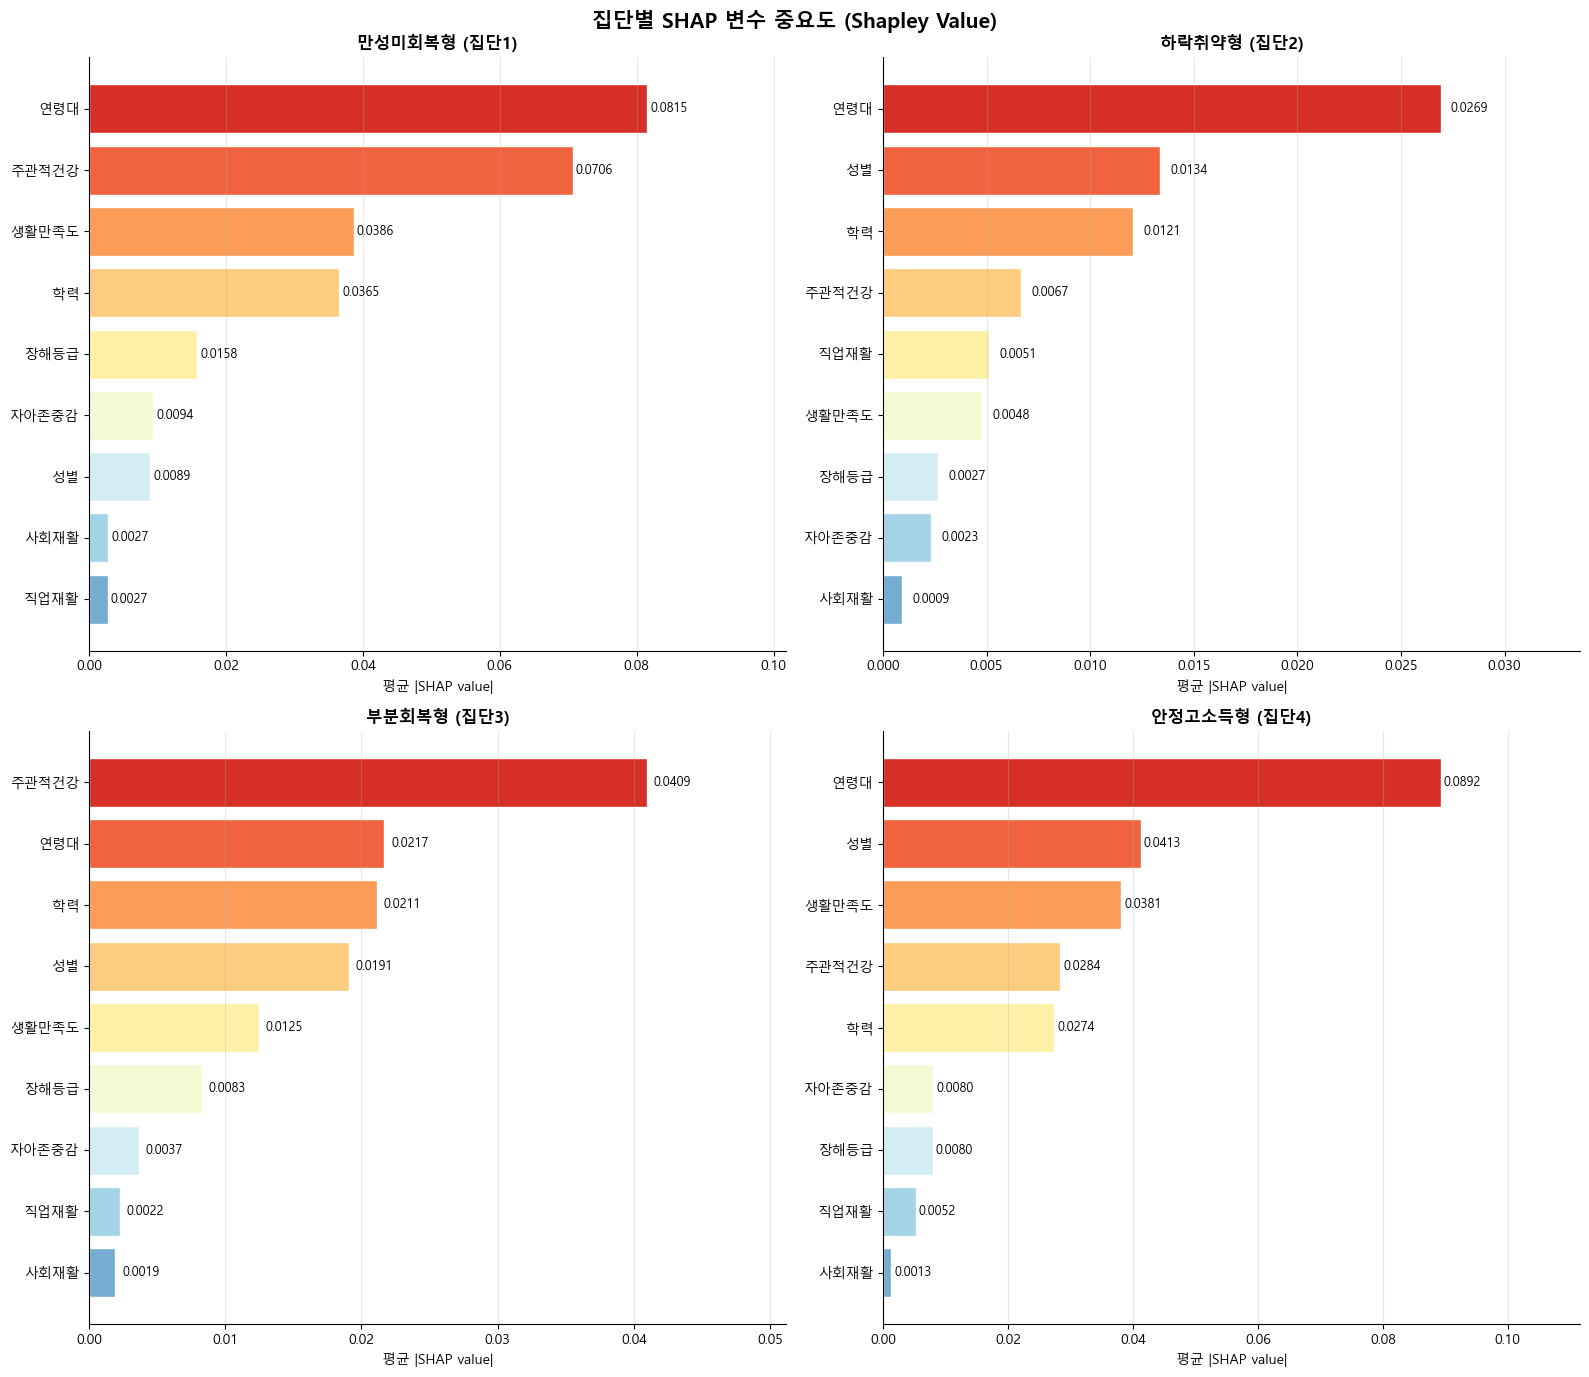

shap_by_class.png 저장 완료


In [124]:
# ============================================================
# 3. 집단별 SHAP 변수 중요도 시각화
# ============================================================

class_names = {
    0: '만성미회복형 (집단1)',
    1: '하락취약형 (집단2)',
    2: '부분회복형 (집단3)',
    3: '안정고소득형 (집단4)'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('집단별 SHAP 변수 중요도 (Shapley Value)',
             fontsize=15, fontweight='bold')

for idx, ax in enumerate(axes.flatten()):
    sv       = shap_values[:, :, idx]           # (2542, 9)
    mean_abs = np.abs(sv).mean(axis=0)          # 변수별 평균 절댓값

    shap_df = pd.DataFrame({
        '변수': X.columns,
        'SHAP': mean_abs
    }).sort_values('SHAP', ascending=True)

    colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.9, len(shap_df)))
    bars   = ax.barh(shap_df['변수'], shap_df['SHAP'],
                     color=colors, edgecolor='white')

    for bar, val in zip(bars, shap_df['SHAP']):
        ax.text(bar.get_width() + 0.0005,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)

    ax.set_title(class_names[idx], fontsize=12, fontweight='bold')
    ax.set_xlabel('평균 |SHAP value|')
    ax.set_xlim(0, shap_df['SHAP'].max() * 1.25)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('shap_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("shap_by_class.png 저장 완료")


전체 변수 중요도 순위 (평균 |SHAP|)
  연령대          0.0548  █████████████████████████
  주관적건강        0.0367  ████████████████
  학력           0.0243  ███████████
  생활만족도        0.0235  ██████████
  성별           0.0206  █████████
  장해등급         0.0087  ███
  자아존중감        0.0058  ██
  직업재활         0.0038  █
  사회재활         0.0017  


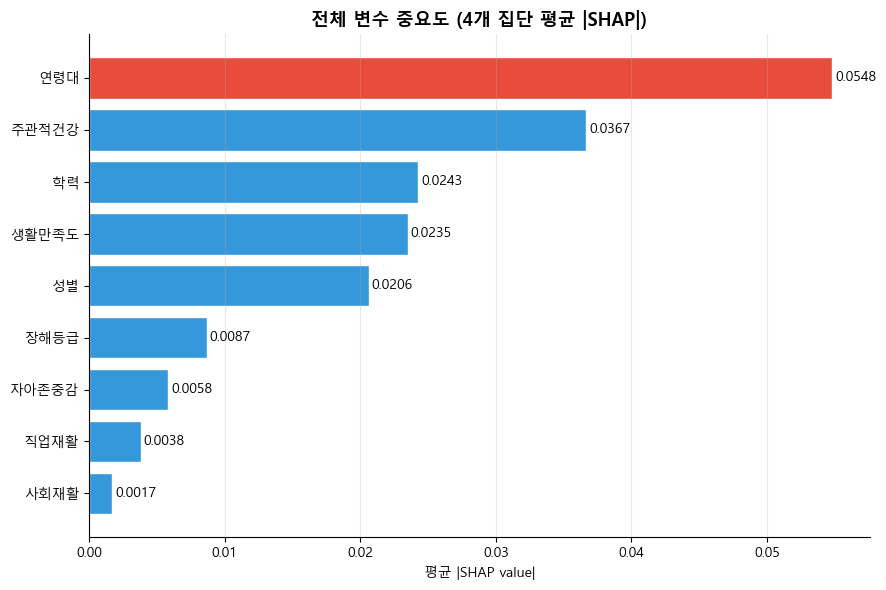

shap_overall.png 저장 완료


In [125]:
# ============================================================
# 4. 전체 변수 중요도 (4개 집단 평균)
# ============================================================

total_shap = np.abs(shap_values).mean(axis=(0, 2))  # (9,)

total_df = pd.DataFrame({
    '변수': X.columns,
    'SHAP': total_shap
}).sort_values('SHAP', ascending=False)

print("\n" + "=" * 45)
print("전체 변수 중요도 순위 (평균 |SHAP|)")
print("=" * 45)
for _, row in total_df.iterrows():
    bar = '█' * int(row['SHAP'] / total_df['SHAP'].max() * 25)
    print(f"  {row['변수']:<12} {row['SHAP']:.4f}  {bar}")

# 전체 중요도 시각화
fig, ax = plt.subplots(figsize=(9, 6))

total_sorted = total_df.sort_values('SHAP', ascending=True)
colors = ['#E74C3C' if v == total_sorted['SHAP'].max()
          else '#3498DB' for v in total_sorted['SHAP']]

bars = ax.barh(total_sorted['변수'], total_sorted['SHAP'],
               color=colors, edgecolor='white')

for bar, val in zip(bars, total_sorted['SHAP']):
    ax.text(bar.get_width() + 0.0002,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_title('전체 변수 중요도 (4개 집단 평균 |SHAP|)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('평균 |SHAP value|')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('shap_overall.png', dpi=150, bbox_inches='tight')
plt.show()
print("shap_overall.png 저장 완료")


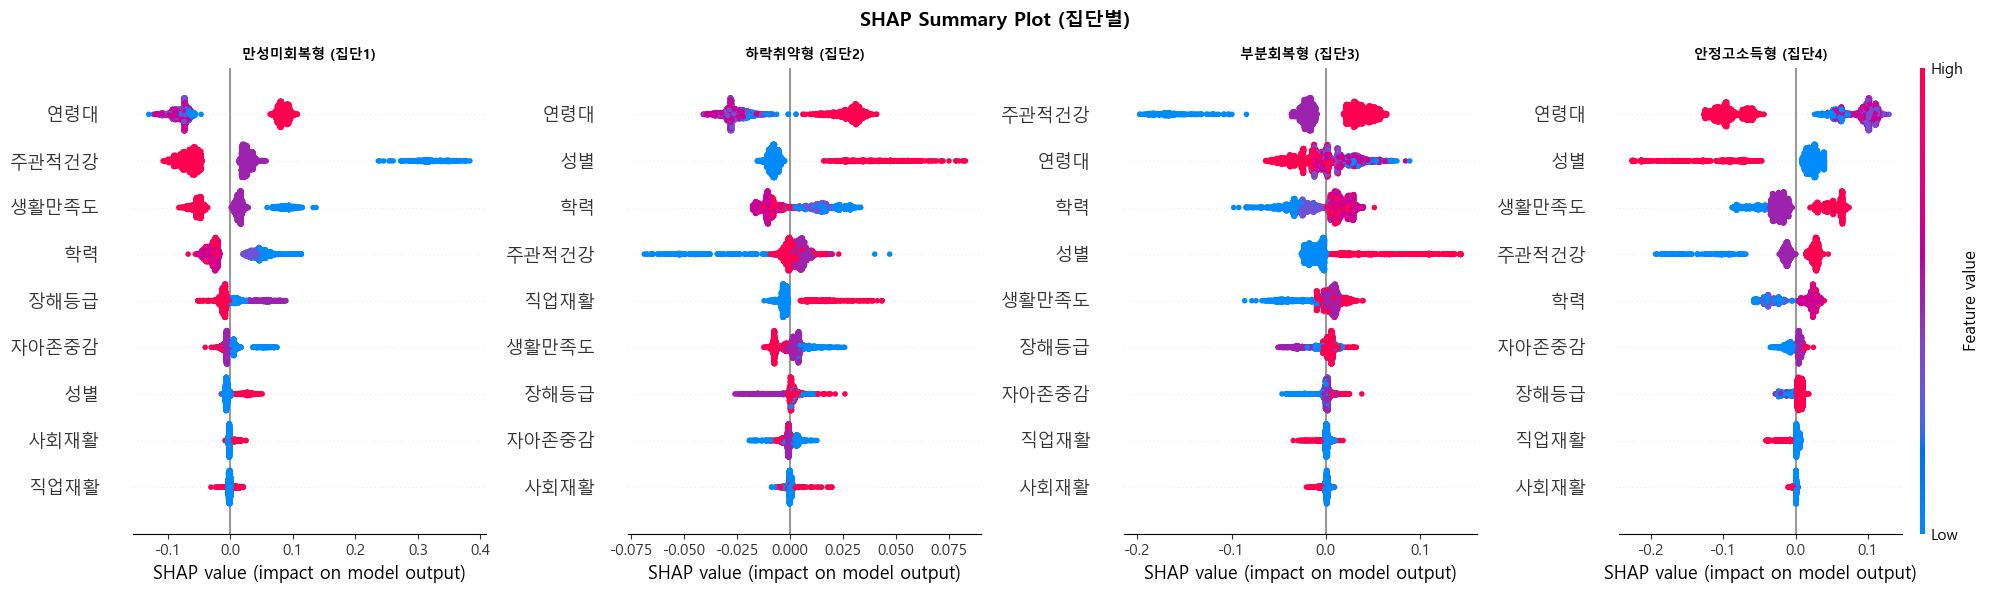

shap_summary.png 저장 완료


In [126]:
# ============================================================
# 5. SHAP Summary Plot (beeswarm) - 집단별
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('SHAP Summary Plot (집단별)',
             fontsize=14, fontweight='bold')

for idx in range(4):
    plt.sca(axes[idx])
    shap.summary_plot(
        shap_values[:, :, idx],
        X,
        plot_type = 'dot',
        show      = False,
        plot_size = None,
        color_bar = (idx == 3)
    )
    axes[idx].set_title(class_names[idx], fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("shap_summary.png 저장 완료")

### SHAP 결과 해석

In [127]:
cols = ['pid', 'RIRI_w3', 'RIRI_w4', 'RIRI_w5',
        'gender', 'age054', 'edu05', 'disa_class',
        'esteem_w1', 'lifesatis_w1', 'G01005001',
        'job_rehab', 'soc_rehab']

existing = [c for c in cols if c in df_lcga.columns]
df_slim = df_lcga[existing]
df_slim.to_csv('riri_slim.csv', index=False)
print(df_slim.shape)
print(df_slim.head(3))

(2542, 13)
   pid    RIRI_w3    RIRI_w4    RIRI_w5  gender  age054  edu05  disa_class  \
0    2   0.000000   0.000000    0.00000       1     2.0    5.0           1   
1    3  46.343108  73.173956  273.46076       1     1.0    4.0           1   
2    4   0.000000   0.000000    0.00000       1     1.0    4.0           1   

   esteem_w1  lifesatis_w1  G01005001  job_rehab  soc_rehab  
0          3             4          2        0.0        1.0  
1          2             2          1        0.0        0.0  
2          2             2          1        0.0        0.0  


In [128]:
# 전체 컬럼 목록 출력
print(df.columns.tolist())

['pid', 'p05', 'nonresponse05', 'workperiod14', 'accident', 'injurytype', 'injurypart', 'con16', 'acc1', 'hire1', 'hire2', 'gender', 'age054', 'edu05', 'area056', 'disa052', 'disa056', 'disa0515', 'service05', 'jobservice05', 'socservice05', 'emp052', 'emp053', 'emp056', 'emp0510', 'wt051', 'wt052', 'A05001001', 'A05001002', 'A05002002', 'A05003001', 'A05004001', 'A05004007', 'A05004003', 'A05004004', 'A05004005', 'A05004006', 'A05005001', 'A05005002', 'A05005A01', 'A05005A02', 'A05005A03', 'A05005A04', 'A05005A05', 'A05005A06', 'A05005B01', 'A05005B02', 'A05005B03', 'A05005B04', 'A05005B05', 'A05005B06', 'A05005C01', 'A05005C02', 'A05005C03', 'A05005C04', 'A05005C05', 'A05005C06', 'A05005D01', 'A05005D02', 'A05005D03', 'A05005D04', 'A05005D05', 'A05005D06', 'A05005E01', 'A05005E02', 'A05005E03', 'A05005E04', 'A05005E05', 'A05005E06', 'A05005F01', 'A05005F02', 'A05005F03', 'A05005F04', 'A05005F05', 'A05005F06', 'A05005G01', 'A05005G02', 'A05005G03', 'A05005G04', 'A05005G05', 'A05005G06

In [130]:
new_cols = ['pid', 'injurytype', 'workperiod14', 'hire1', 'hire2',
            'E205008001', 'E205001002', 'E205007003', 'E205012001',
            'A05002002', 'con16', 'acc1']

df_new = df_lcga[new_cols]
df_new.to_csv('riri_new_vars.csv', index=False)
print(df_new.shape)
print(df_new.head(3))

(2542, 12)
   pid  injurytype  workperiod14  hire1  hire2  E205008001  E205001002  \
0    2          13            10   2008     11         NaN         NaN   
1    3           1             7   2013      6         2.0         6.0   
2    4          13            12   2009      3         NaN         NaN   

   E205007003  E205012001  A05002002  con16  acc1  
0         NaN         NaN        1.0      6  2012  
1         3.0         2.0        2.0      6  2014  
2         NaN         NaN        2.0      6  2015  
